In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [ ]:
df = pd.read_csv('/content/sample_data/Dataset.csv')

In [ ]:
df.sample(6)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
2351,2352,38,Male,Sweater,Clothing,50,New Hampshire,S,Cyan,Fall,4.9,No,Store Pickup,No,No,25,PayPal,Bi-Weekly
3265,3266,40,Female,Sunglasses,Accessories,100,Alabama,M,White,Winter,3.2,No,Express,No,No,28,Credit Card,Fortnightly
2814,2815,31,Female,T-shirt,Clothing,32,Minnesota,L,Gold,Winter,3.6,No,Standard,No,No,14,Bank Transfer,Monthly
1706,1707,37,Male,Sunglasses,Accessories,87,North Dakota,M,Brown,Spring,3.0,No,Standard,No,No,25,Venmo,Fortnightly
468,469,34,Male,Backpack,Accessories,38,Georgia,S,Peach,Fall,5.0,Yes,Free Shipping,Yes,Yes,16,Cash,Quarterly
1644,1645,68,Male,Coat,Outerwear,90,North Carolina,S,Beige,Summer,3.9,No,Next Day Air,Yes,Yes,21,Debit Card,Monthly


In [ ]:
print(df['Shipping Type'].unique())
print(df['Location'].unique())

['Express' 'Free Shipping' 'Next Day Air' 'Standard' '2-Day Shipping'
 'Store Pickup']
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']


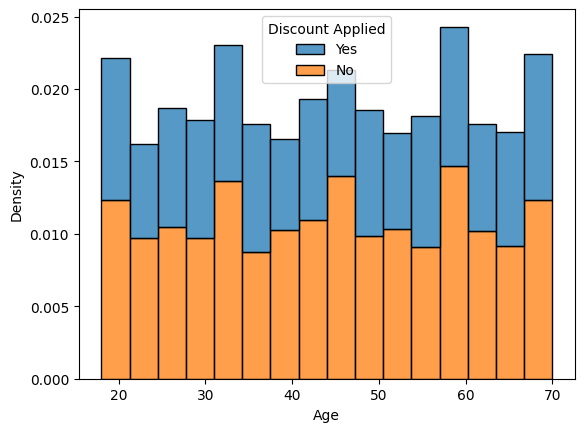

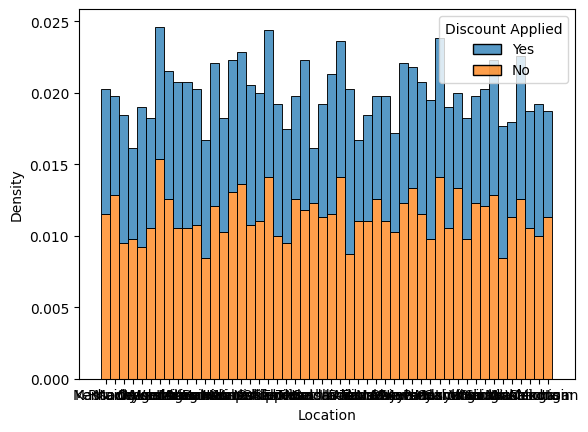

In [ ]:
sns.histplot(x=df['Age'],
             hue=df['Discount Applied'],
             multiple='stack',
             stat ='density')
plt.show()
sns.histplot(x=df['Location'],
             hue=df['Discount Applied'],
             multiple='stack',
             stat ='density')
plt.show()

In [ ]:
# 1. Calculate Average Order Value (AOV) for Discount vs No Discount
aov_discount = df[df["Discount Applied"] == "Yes"]["Purchase Amount (USD)"].mean()
aov_regular = df[df["Discount Applied"] == "No"]["Purchase Amount (USD)"].mean()

print(f"Average Spend with Discount: ${aov_discount:.2f}")
print(f"Average Spend without Discount: ${aov_regular:.2f}")

# 2. Check if discounts make people buy lower-rated items or clear out inventory
avg_rating_discount = df[df["Discount Applied"] == "Yes"]["Review Rating"].mean()
avg_rating_regular = df[df["Discount Applied"] == "No"]["Review Rating"].mean()

print(f"avg_rating_discount: ${avg_rating_discount:.2f}")
print(f"avg_rating_regular: ${avg_rating_regular:.2f}")

# 3. Calculate "Incremental Revenue" to see the true impact
total_discount_sales = df[df["Discount Applied"] == "Yes"][
    "Purchase Amount (USD)"
].sum()
total_regular_sales = df[df["Discount Applied"] == "No"][
    "Purchase Amount (USD)"
].sum()

print(f"total_discount_sales: ${total_discount_sales:.2f}")
print(f"total_regular_sales: ${total_regular_sales:.2f}")

# 4. Statistical Check: T-test to prove if the difference is real or just luck
from scipy import stats

discount_amounts = df[df["Discount Applied"] == "Yes"]["Purchase Amount (USD)"]
regular_amounts = df[df["Discount Applied"] == "No"]["Purchase Amount (USD)"]

t_stat, p_val = stats.ttest_ind(discount_amounts, regular_amounts)
if p_val < 0.05:
    print("The discount has a statistically significant impact on sales amounts!")
else:
    print(
        "No significant difference. The discount is likely wasting your margin."
    )


Average Spend with Discount: $59.28
Average Spend without Discount: $60.13
avg_rating_discount: $3.74
avg_rating_regular: $3.76
total_discount_sales: $99411.00
total_regular_sales: $133670.00
No significant difference. The discount is likely wasting your margin.


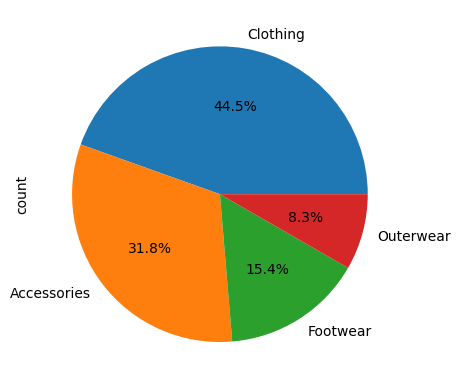

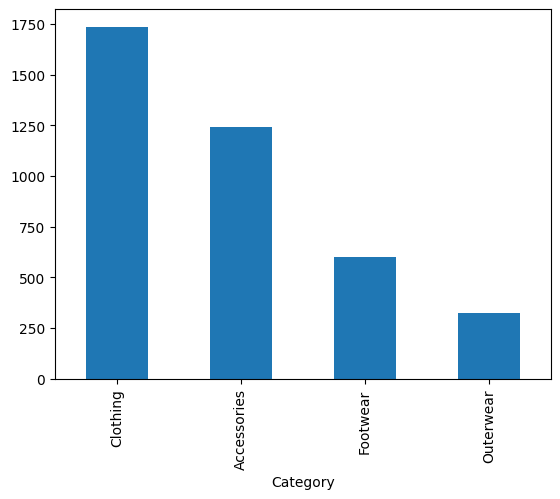

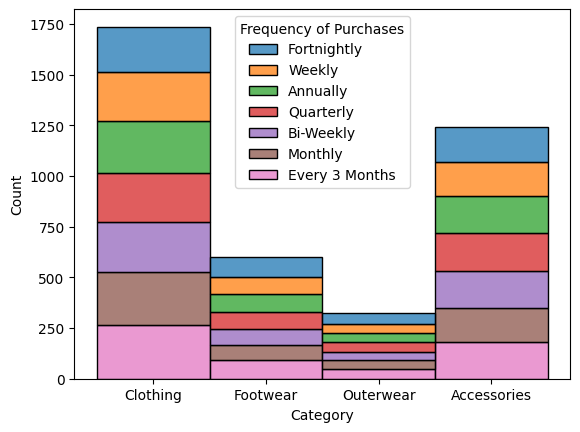

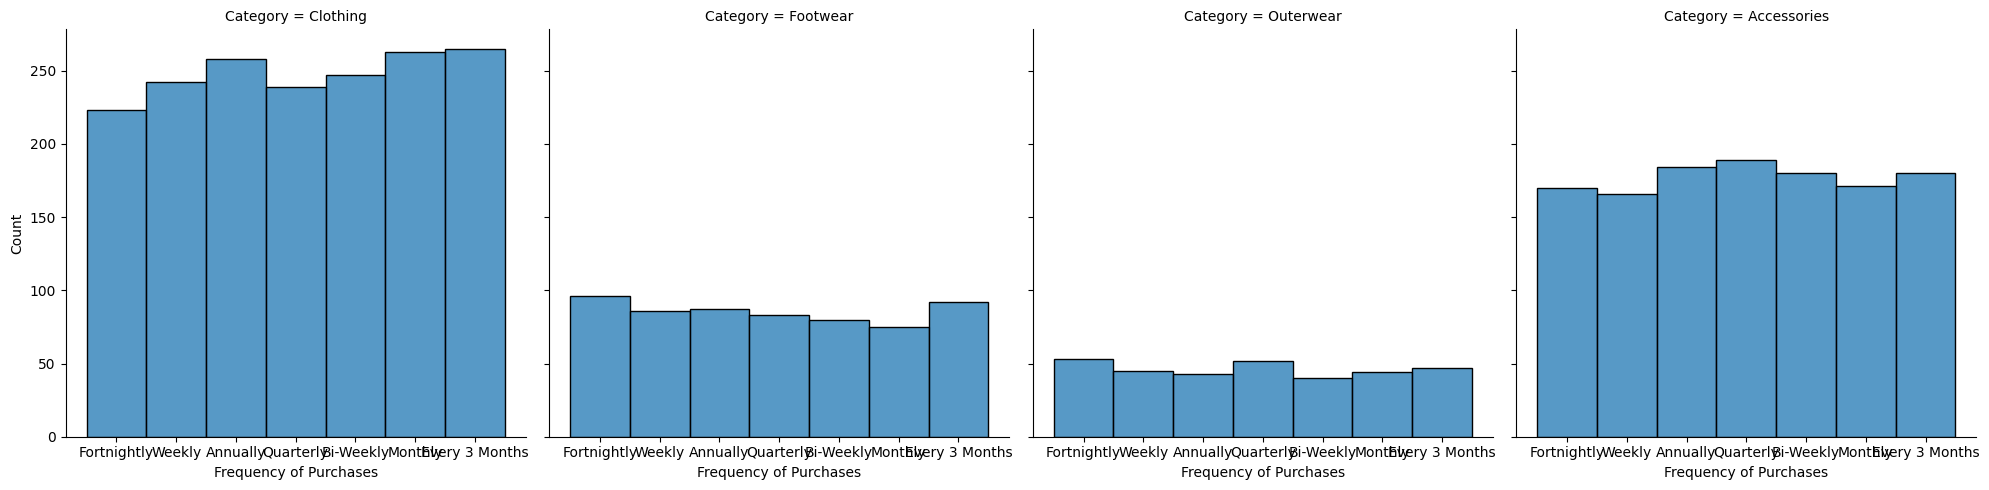

In [ ]:
# product distribution
df['Category'].value_counts().plot.pie(autopct ='%1.1f%%')
plt.show()
df['Category'].value_counts().plot.bar()
plt.show()
sns.histplot(x=df['Category'],hue=df['Frequency of Purchases'],multiple='stack')
plt.show()
sns.displot(
    data=df,
    x='Frequency of Purchases',
    col='Category',        # separate subplot for each category
    stat='count',          # or 'density'
    bins=7,                # 7 bars per category
    common_norm=False      # keeps each category independent
)
plt.show()

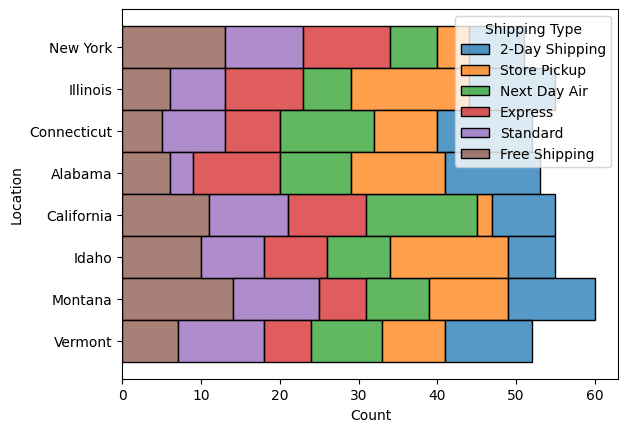

In [ ]:
df_no_discount = df[df['Discount Applied']=='No']
category_counts = df_no_discount['Location'].value_counts()
categories_to_plot = category_counts[category_counts > 50].index

df_filtered = df_no_discount[df_no_discount['Location'].isin(categories_to_plot)]

sns.histplot(data=df_filtered, y='Location', hue='Shipping Type', multiple='stack')
plt.show()

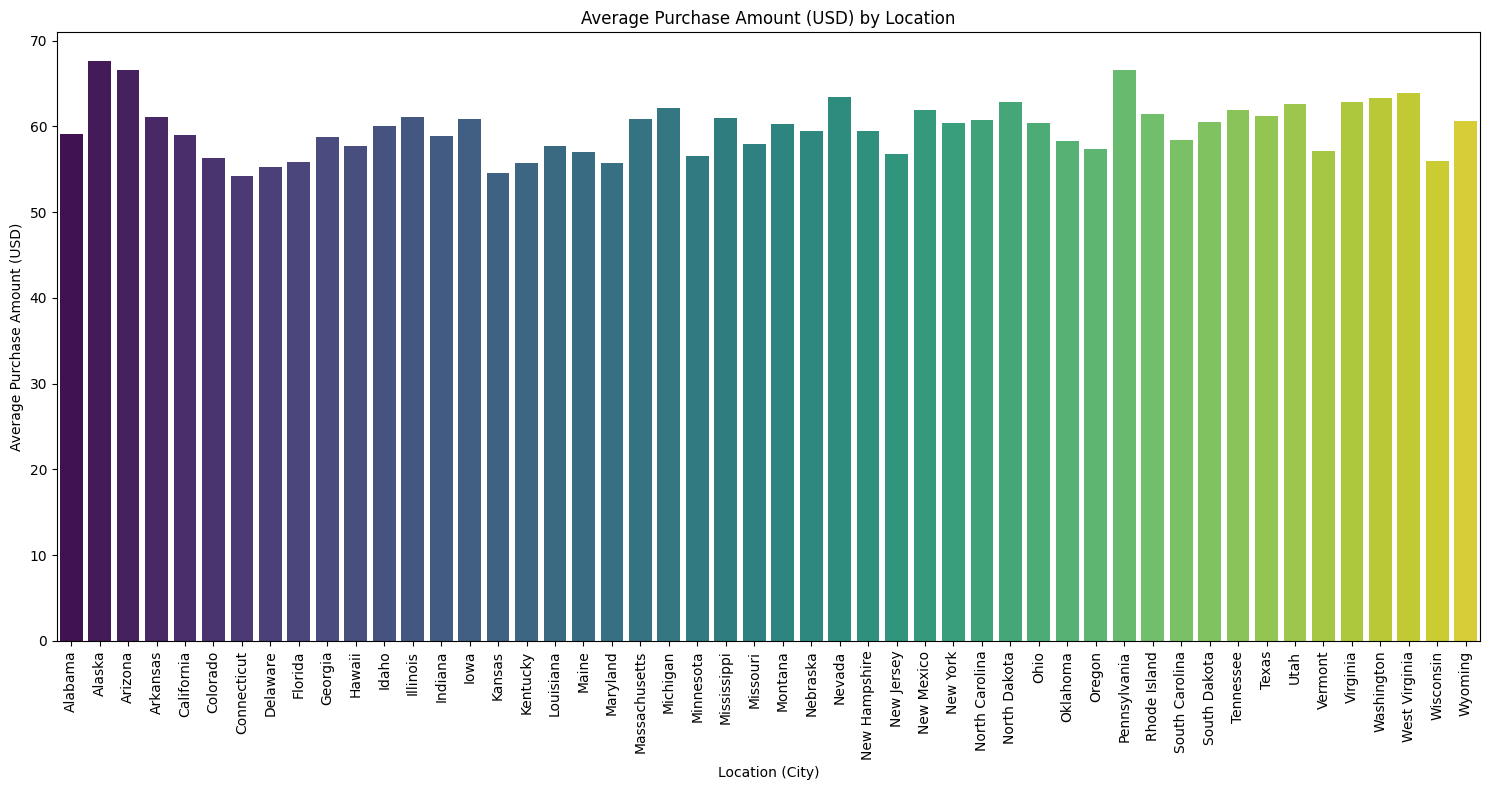

In [ ]:
avg_spend_by_location = df.groupby('Location')['Purchase Amount (USD)'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=avg_spend_by_location, x='Location', y='Purchase Amount (USD)', palette='viridis')
plt.title('Average Purchase Amount (USD) by Location')
plt.xlabel('Location (City)')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

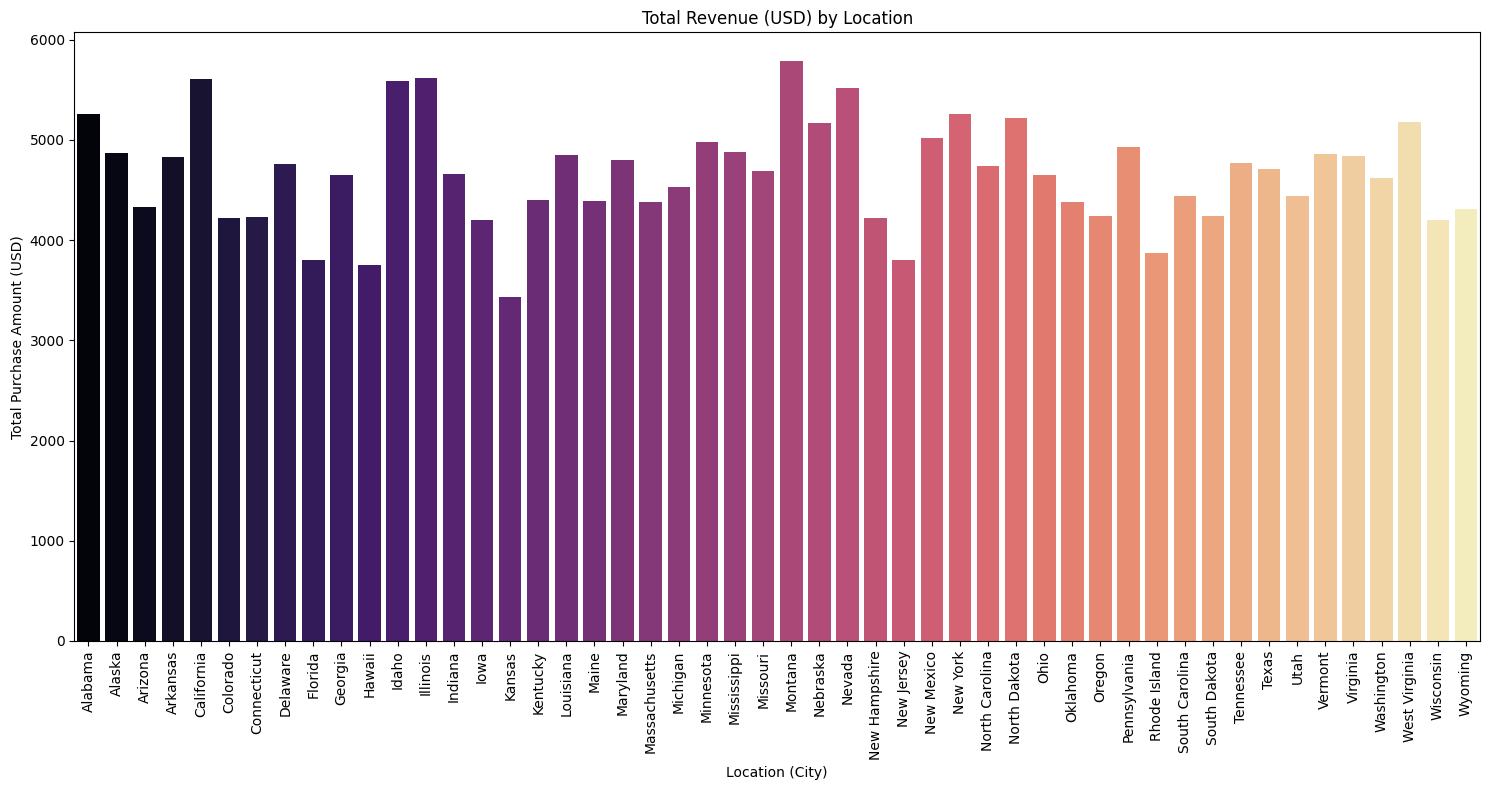

In [ ]:
total_revenue_by_location = df.groupby('Location')['Purchase Amount (USD)'].sum().reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=total_revenue_by_location, x='Location', y='Purchase Amount (USD)', palette='magma')
plt.title('Total Revenue (USD) by Location')
plt.xlabel('Location (City)')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

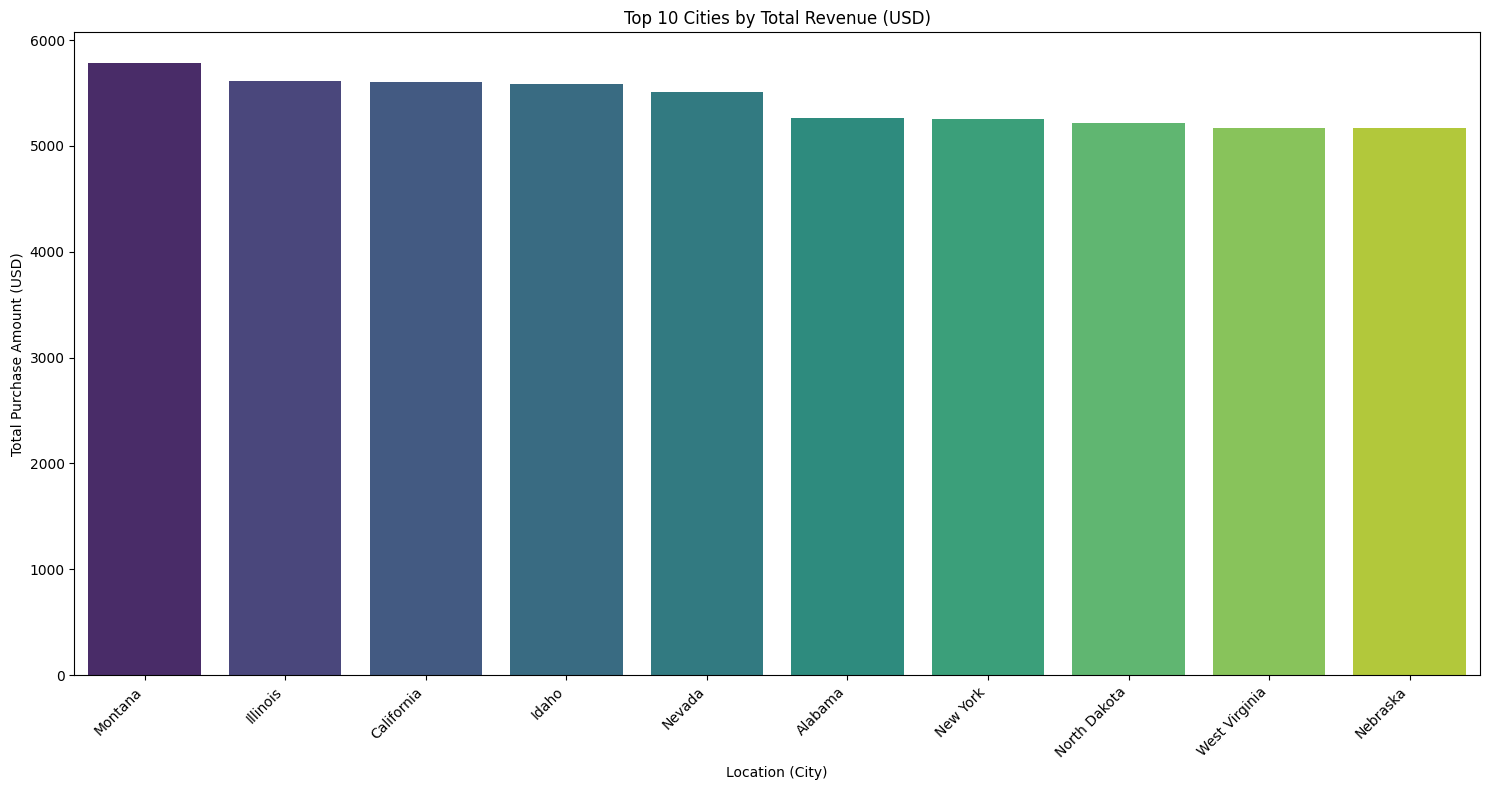

In [ ]:
top_10_revenue_cities = total_revenue_by_location.sort_values(by='Purchase Amount (USD)', ascending=False).head(10)

plt.figure(figsize=(15, 8))
sns.barplot(data=top_10_revenue_cities, x='Location', y='Purchase Amount (USD)', palette='viridis')
plt.title('Top 10 Cities by Total Revenue (USD)')
plt.xlabel('Location (City)')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

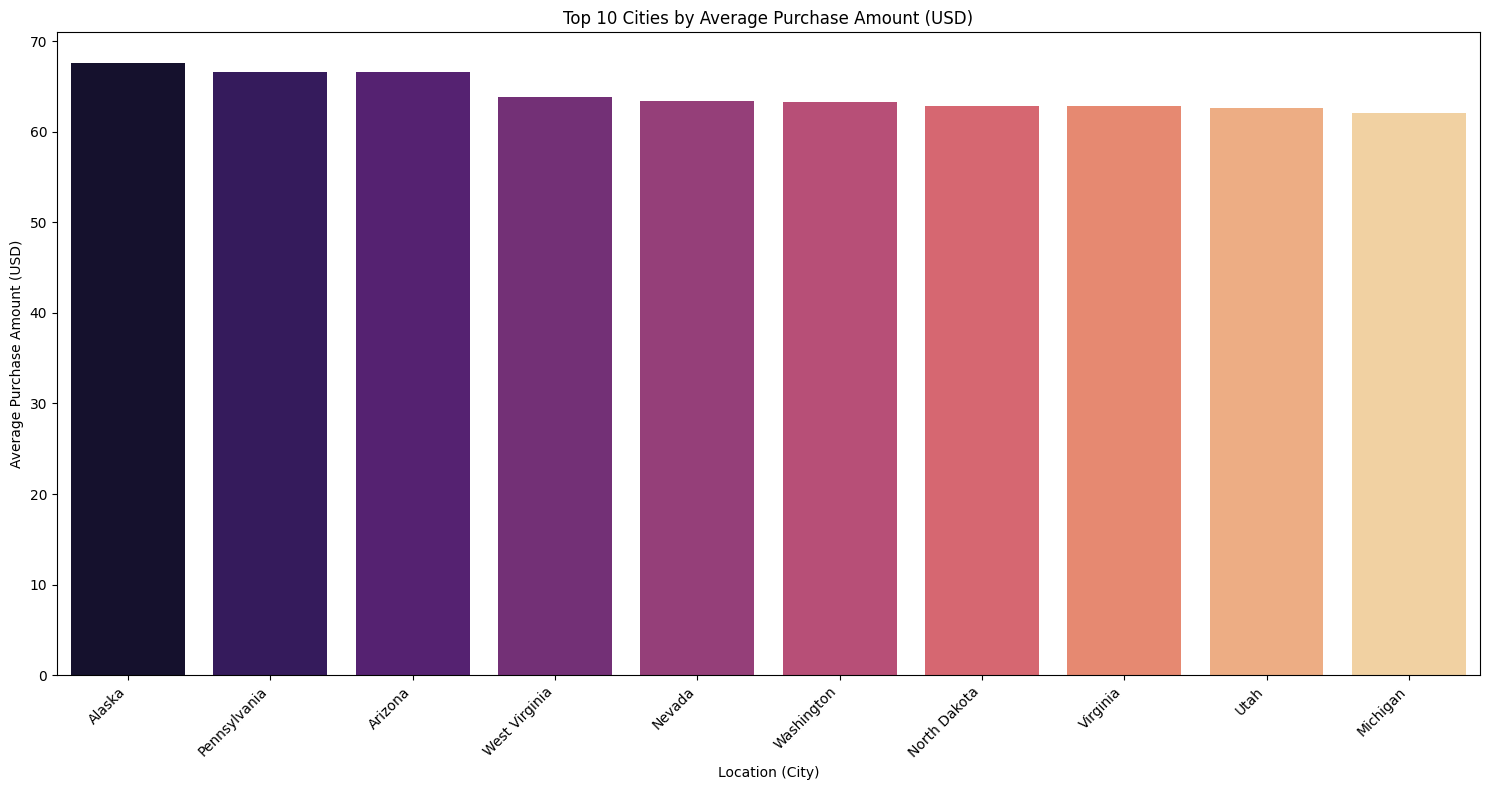

In [ ]:
top_10_avg_spend_cities = avg_spend_by_location.sort_values(by='Purchase Amount (USD)', ascending=False).head(10)

plt.figure(figsize=(15, 8))
sns.barplot(data=top_10_avg_spend_cities, x='Location', y='Purchase Amount (USD)', palette='magma')
plt.title('Top 10 Cities by Average Purchase Amount (USD)')
plt.xlabel('Location (City)')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

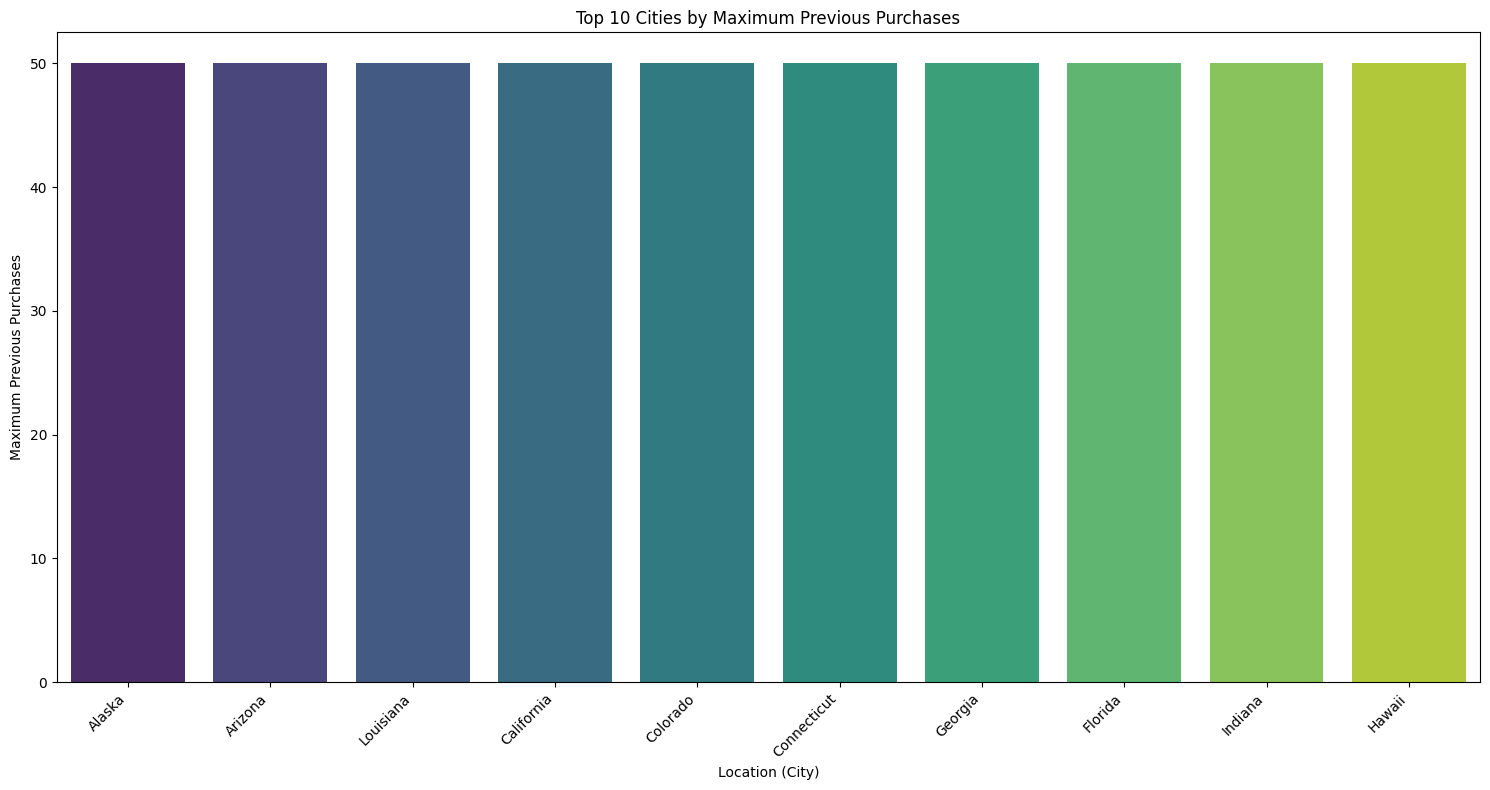

In [ ]:
max_prev_purchases_by_location = df.groupby('Location')['Previous Purchases'].max().reset_index()

top_10_max_prev_purchases_cities = max_prev_purchases_by_location.sort_values(by='Previous Purchases', ascending=False).head(10)

plt.figure(figsize=(15, 8))
sns.barplot(data=top_10_max_prev_purchases_cities, x='Location', y='Previous Purchases', palette='viridis')
plt.title('Top 10 Cities by Maximum Previous Purchases')
plt.xlabel('Location (City)')
plt.ylabel('Maximum Previous Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df['Shipping Type'].value_counts()

,count
Shipping Type,
Free Shipping,675
Standard,654
Store Pickup,650
Next Day Air,648
Express,646
2-Day Shipping,627


### Finding Cities in High-Performing Categories

I will now analyze the previously generated 'top 10' lists to identify cities that excel in:

1.  **High Average Purchase Amount** (`top_10_avg_spend_cities`)
2.  **High Total Revenue** (`top_10_revenue_cities`)
3.  **High Maximum Previous Purchases** (`top_10_max_prev_purchases_cities`)

First, I'll find cities that appear in *all three* categories, and then I'll identify cities that appear in *any two* of these categories.

In [ ]:
avg_spend_cities = set(top_10_avg_spend_cities['Location'])
total_revenue_cities = set(top_10_revenue_cities['Location'])
max_prev_purchases_cities = set(top_10_max_prev_purchases_cities['Location'])

# Cities in all three categories
cities_in_all_three = avg_spend_cities.intersection(total_revenue_cities, max_prev_purchases_cities)
print(f"Cities in all three (High Avg Spend, High Total Revenue, High Max Previous Purchases): {list(cities_in_all_three)}")

# Cities in any two categories
cities_in_avg_and_total = avg_spend_cities.intersection(total_revenue_cities)
cities_in_avg_and_prev = avg_spend_cities.intersection(max_prev_purchases_cities)
cities_in_total_and_prev = total_revenue_cities.intersection(max_prev_purchases_cities)

# Combine and get unique cities that appear in at least two lists
cities_in_any_two = (cities_in_avg_and_total.union(cities_in_avg_and_prev).union(cities_in_total_and_prev)) - cities_in_all_three

print(f"Cities in any two categories (excluding those in all three): {list(cities_in_any_two)}")

Cities in all three (High Avg Spend, High Total Revenue, High Max Previous Purchases): []
Cities in any two categories (excluding those in all three): ['Nevada', 'Arizona', 'Alaska', 'California', 'North Dakota', 'West Virginia']


In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
df.sample(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
2822,2823,61,Female,Skirt,Clothing,37,New Jersey,S,Brown,Fall,4.1,No,Standard,No,No,33,PayPal,Quarterly
883,884,28,Male,Sneakers,Footwear,37,Pennsylvania,S,Gold,Fall,4.3,Yes,Free Shipping,Yes,Yes,30,Bank Transfer,Monthly
2947,2948,52,Female,Jewelry,Accessories,63,Nebraska,L,Peach,Spring,4.4,No,Standard,No,No,50,Venmo,Annually
1041,1042,36,Male,Shirt,Clothing,25,Minnesota,M,Orange,Summer,4.9,Yes,Next Day Air,Yes,Yes,11,Cash,Fortnightly
1984,1985,26,Male,Skirt,Clothing,58,West Virginia,M,Black,Summer,3.4,No,2-Day Shipping,No,No,26,PayPal,Fortnightly
750,751,25,Male,T-shirt,Clothing,95,Maryland,L,Violet,Fall,3.4,Yes,Free Shipping,Yes,Yes,5,Venmo,Annually
3589,3590,31,Female,Belt,Accessories,73,New Hampshire,M,Blue,Spring,4.8,No,Next Day Air,No,No,38,Cash,Every 3 Months
3586,3587,33,Female,Hoodie,Clothing,28,Idaho,M,Yellow,Winter,4.6,No,Store Pickup,No,No,12,PayPal,Bi-Weekly
3691,3692,63,Female,Sandals,Footwear,21,Michigan,XL,Orange,Summer,4.8,No,Next Day Air,No,No,24,PayPal,Weekly
3167,3168,24,Female,Dress,Clothing,78,Oregon,M,Blue,Fall,2.8,No,2-Day Shipping,No,No,9,Cash,Bi-Weekly


In [ ]:
df_best_ideal_loyal_customer = df[
    (df['Purchase Amount (USD)'] >= 39) &
    (df['Review Rating'] >= 3) &
    (df['Previous Purchases'] >= 5) &

    (df['Subscription Status'] == 'Yes') &

    (df['Frequency of Purchases'] == 'Weekly')
]

In [ ]:
df_best_ideal_loyal_customer.shape


(94, 18)

In [ ]:
df_best_ideal_loyal_customer = df[
    (df['Purchase Amount (USD)'] >= 39) &
    (df['Review Rating'] >= 3) &
    (df['Previous Purchases'] >= 5) &
    (df['Discount Applied'] == 'No') &

    (df['Promo Code Used'] == 'No') &
    (df['Frequency of Purchases'] == 'Weekly')
]


In [ ]:
df_best_ideal_loyal_customer.shape

(174, 18)

<Axes: xlabel='Age', ylabel='Count'>

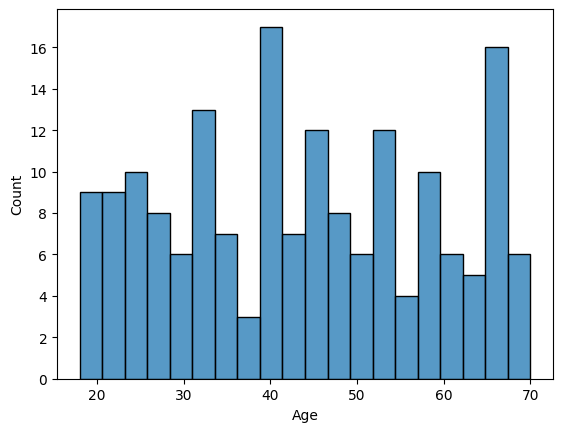

In [ ]:
sns.histplot(df_best_ideal_loyal_customer['Age'],bins=20)

<Axes: xlabel='Age', ylabel='Density'>

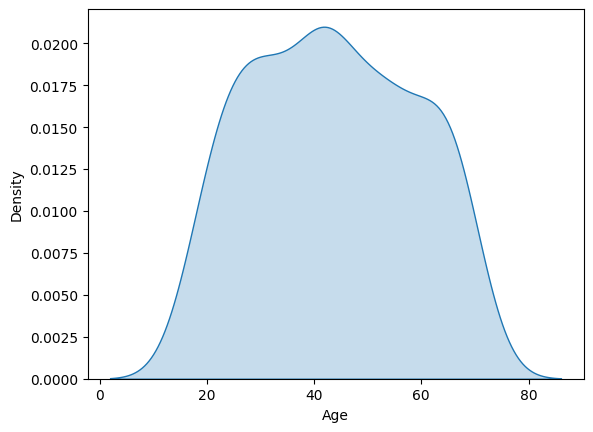

In [ ]:
sns.kdeplot(df_best_ideal_loyal_customer['Age'],shade=True)

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
df['Review Rating'].fillna(df['Review Rating'].mean(),inplace=True)

In [ ]:

# 1. Calculate Purchase Amount Score
# Apply conditional weight
df["Purchase_Weight"] = np.where(df["Purchase Amount (USD)"] > 39, 3.0, 1.5)
# Max normalization of the raw value, then multiply by its conditional weight
df["Purchase_Norm"] = (
    df["Purchase Amount (USD)"] / df["Purchase Amount (USD)"].max()
)
df["Purchase_Final"] = df["Purchase_Norm"] * df["Purchase_Weight"]

# 2. Calculate Previous Purchases Score
# Apply conditional weight
df["Prev_Purchases_Weight"] = np.where(df["Previous Purchases"] > 5, 3.0, 1.5)
# Max normalization of the raw value, then multiply by its conditional weight
df["Prev_Purchases_Norm"] = (
    df["Previous Purchases"] / df["Previous Purchases"].max()
)
df["Prev_Purchases_Final"] = (
    df["Prev_Purchases_Norm"] * df["Prev_Purchases_Weight"]
)

# 3. Calculate Subscription Score
# Assign a fixed score of 2 if Subscribed ('Yes'), else 0
df["Sub_Final"] = df["Subscription Status"].apply(lambda x: 2.0 if x == "Yes" else 0.0)

# 4. Calculate Frequency Score
# Map recurring purchasing behavior to a score out of 2.0
freq_mapping = {"Weekly": 2.0, "Fortnightly": 1.5, "Monthly": 1.0, "Annually": 0.5}
df["Freq_Final"] = df["Frequency of Purchases"].map(freq_mapping).fillna(0.0)

# 5. Apply Penalty for Discount Hunters
# Penalty of -1 if a discount was applied, else 0 points
df["Discount_Penalty"] = df["Discount Applied"].apply(
    lambda x: -1.0 if x == "Yes" else 0.0
)
df["Promo_Penalty"] = df["Promo Code Used"].apply(
    lambda x: -1.0 if x == "Yes" else 0.0
)

# 6. Final Loyalty Score Calculation
# Sum up all calculated pillars to get the final score
df["Loyalty_Score"] = (
    df["Purchase_Final"]
    + df["Prev_Purchases_Final"]
    + df["Sub_Final"]
    + df["Freq_Final"]
    + df["Discount_Penalty"]
    + df["Promo_Penalty"]
)

# Display results ordered by your most loyal customers
print(df.sort_values(by="Loyalty_Score", ascending=False))

      Customer ID  Age  Gender Item Purchased     Category  \
992           993   46    Male         Jacket    Outerwear   
1847         1848   46    Male        Sandals     Footwear   
2445         2446   63    Male          Scarf  Accessories   
3581         3582   26  Female          Dress     Clothing   
2288         2289   28    Male        Jewelry  Accessories   
...           ...  ...     ...            ...          ...   
1641         1642   50    Male         Hoodie     Clothing   
1422         1423   44    Male          Dress     Clothing   
1441         1442   34    Male          Pants     Clothing   
1065         1066   59    Male        T-shirt     Clothing   
1663         1664   43    Male          Shirt     Clothing   

      Purchase Amount (USD)    Location Size      Color  Season  ...  \
992                      99   Louisiana    M       Gray  Winter  ...   
1847                    100     Arizona   XL       Cyan  Summer  ...   
2445                     96   Tennessee

<Axes: xlabel='Loyalty_Score', ylabel='Density'>

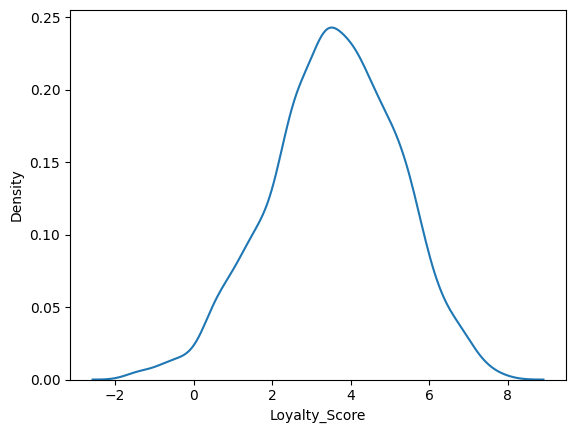

In [ ]:
sns.kdeplot(df['Loyalty_Score'])

In [ ]:
df[(df['Review Rating']<3)&(df['Loyalty_Score']>4)]['Loyalty_Score'].shape[0]

265

In [ ]:
df[(df['Loyalty_Score']>4)]['Loyalty_Score'].shape[0]/df.shape[0]

0.40564102564102567

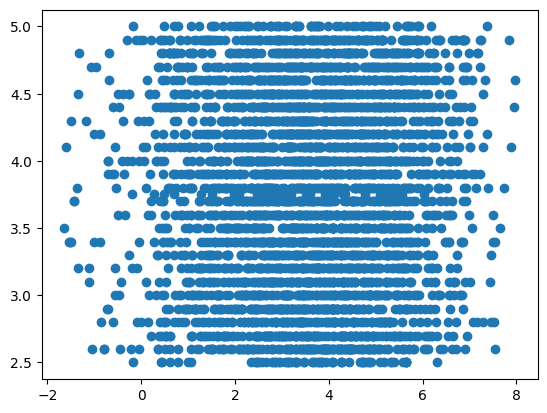

In [ ]:
plt.scatter(x=df['Loyalty_Score'],y=df['Review Rating'])

In [ ]:
print(265/df.shape[0])

0.06794871794871794


In [ ]:
df.shape

(3900, 29)

In [ ]:
# --- PRE-PROCESSING: Handle extreme outliers (Tweak C) ---
# If one shopper has 500 orders, it ruins max normalisation for everyone else.
# We cap the continuous columns at a reasonable business ceiling.
purchase_cap = df["Purchase Amount (USD)"].quantile(0.99)  # Top 1% ceiling
prev_purchases_cap = df["Previous Purchases"].quantile(0.99)

df["Purchase_Clipped"] = df["Purchase Amount (USD)"].clip(upper=purchase_cap)
df["Prev_Purchases_Clipped"] = df["Previous Purchases"].clip(
    upper=prev_purchases_cap
)

# --- 1. Purchase Amount Pillar (Constant Weight + Threshold Bonus) ---
# Normalize the clipped value (0 to 1) and apply a rock-solid weight of 1.5
df["Purchase_Norm"] = df["Purchase_Clipped"] / df["Purchase_Clipped"].max()
df["Purchase_Base"] = df["Purchase_Norm"] * 1.5
# Award a flat bonus point if they cross your $39 threshold (Fixes Tweak A)
df["Purchase_Bonus"] = np.where(df["Purchase Amount (USD)"] > 39, 1.5, 0.0)
df["Purchase_Final"] = df["Purchase_Base"] + df["Purchase_Bonus"]

# --- 2. Previous Purchases Pillar (Constant Weight + Threshold Bonus) ---
# Normalize the clipped value (0 to 1) and apply a rock-solid weight of 1.5
df["Prev_Purchases_Norm"] = (
    df["Prev_Purchases_Clipped"] / df["Prev_Purchases_Clipped"].max()
)
df["Prev_Purchases_Base"] = df["Prev_Purchases_Norm"] * 1.5
# Award a flat bonus point if they cross your 5 previous purchases threshold
df["Prev_Purchases_Bonus"] = np.where(df["Previous Purchases"] > 5, 1.5, 0.0)
df["Prev_Purchases_Final"] = (
    df["Prev_Purchases_Base"] + df["Prev_Purchases_Bonus"]
)

# --- 3. Subscription Pillar ---
df["Sub_Final"] = df["Subscription Status"].apply(lambda x: 2.0 if x == "Yes" else 0.0)

# --- 4. Frequency Pillar ---
freq_mapping = {"Weekly": 2.0, "Fortnightly": 1.5, "Monthly": 1.0, "Annually": 0.5}
df["Freq_Final"] = df["Frequency of Purchases"].map(freq_mapping).fillna(0.0)

# --- 5. Penalty Pillar ---
df["Discount_Penalty"] = df["Discount Applied"].apply(
    lambda x: -1.0 if x == "Yes" else 0.0
)
df["Promo_Penalty"] = df["Promo Code Used"].apply(
    lambda x: -1.0 if x == "Yes" else 0.0
)
# --- 6. Raw Score Summation ---
df["Raw_Loyalty_Score"] = (
    df["Purchase_Final"]
    + df["Prev_Purchases_Final"]
    + df["Sub_Final"]
    + df["Freq_Final"]
    + df["Discount_Penalty"]
    + df["Promo_Penalty"]
)

# --- 7. Final Clean Scale: 0 to 100 (Tweak B) ---
# This scales the final output cleanly so business teams can understand it.
min_raw = df["Raw_Loyalty_Score"].min()
max_raw = df["Raw_Loyalty_Score"].max()

# Prevent division by zero if all scores are identical
if max_raw - min_raw > 0:
    df["Loyalty_Score_100"] = (
        (df["Raw_Loyalty_Score"] - min_raw) / (max_raw - min_raw)
    ) * 100
else:
    df["Loyalty_Score_100"] = 100.0

<Axes: xlabel='Loyalty_Score_100', ylabel='Density'>

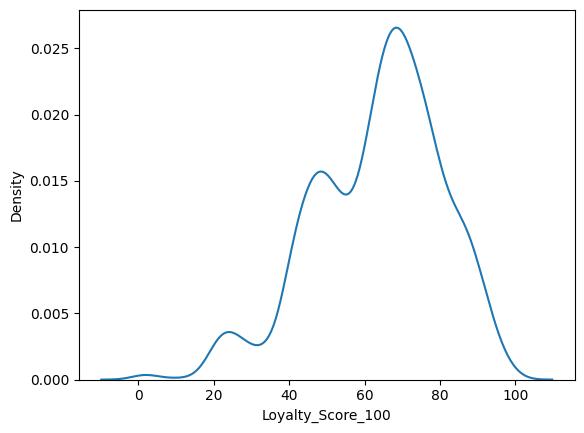

In [ ]:
sns.kdeplot(df['Loyalty_Score_100'])

In [ ]:
df[(df['Loyalty_Score_100']>60)&(df['Review Rating']>3)].shape[0]/df.shape[0]

0.49666666666666665

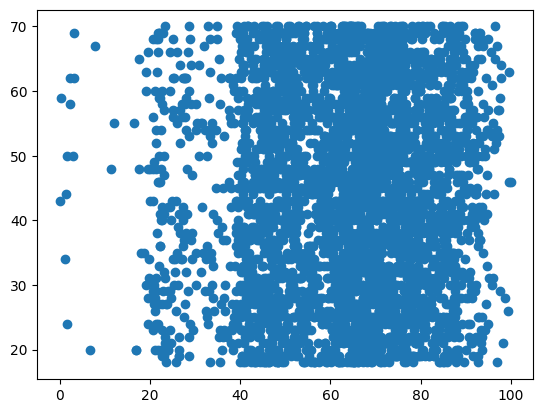

In [ ]:
plt.scatter(x=df['Loyalty_Score_100'],y=df['Age'])

In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'Purchase_Weight',
       'Purchase_Norm', 'Purchase_Final', 'Prev_Purchases_Weight',
       'Prev_Purchases_Norm', 'Prev_Purchases_Final', 'Sub_Final',
       'Freq_Final', 'Discount_Penalty', 'Promo_Penalty', 'Loyalty_Score',
       'Purchase_Clipped', 'Prev_Purchases_Clipped', 'Purchase_Base',
       'Purchase_Bonus', 'Prev_Purchases_Base', 'Prev_Purchases_Bonus',
       'Raw_Loyalty_Score', 'Loyalty_Score_100'],
      dtype='object')

In [ ]:
df = df.drop(columns = ['Purchase_Weight',
       'Purchase_Norm', 'Purchase_Final', 'Prev_Purchases_Weight',
       'Prev_Purchases_Norm', 'Prev_Purchases_Final', 'Sub_Final',
       'Freq_Final', 'Discount_Penalty', 'Promo_Penalty',
       'Purchase_Clipped', 'Prev_Purchases_Clipped', 'Purchase_Base',
       'Purchase_Bonus', 'Prev_Purchases_Base', 'Prev_Purchases_Bonus',
       'Raw_Loyalty_Score',])

In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'Loyalty_Score',
       'Loyalty_Score_100'],
      dtype='object')

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare features
features = ['Purchase Amount (USD)', 'Previous Purchases', 'Review Rating']
X = df[features].copy()
# Convert categorical to numeric
X['Sub_Num'] = df['Subscription Status'].map({'Yes': 1, 'No': 0})
freq_map = {'Weekly': 4, 'Fortnightly': 2, 'Monthly': 1, 'Annually': 0.5}
X['Freq_Num'] = df['Frequency of Purchases'].map(freq_map).fillna(0)

# Scale and cluster
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
# Convert cluster to a "value score" (rank clusters by avg purchase)
cluster_rank = df.groupby('Cluster')['Purchase Amount (USD)'].mean().rank().to_dict()
df['Metric_2_Cluster'] = df['Cluster'].map(cluster_rank) * 25  # Scale 0-100

In [ ]:
df['Metric_2_Cluster']

,Metric_2_Cluster
0,75.0
1,75.0
2,50.0
3,50.0
4,75.0
...,...
3895,50.0
3896,25.0
3897,25.0
3898,50.0


In [ ]:
# Simpler continuous metric
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Purchase_Norm_Simple'] = scaler.fit_transform(df[['Purchase Amount (USD)']])
df['Prev_Purchases_Norm_Simple'] = scaler.fit_transform(df[['Previous Purchases']])
df['Sub_Binary'] = df['Subscription Status'].map({'Yes': 1, 'No': 0})
freq_scores = {'Weekly': 1.0, 'Fortnightly': 0.8, 'Monthly': 0.6, 'Annually': 0.3}
df['Freq_Score'] = df['Frequency of Purchases'].map(freq_scores).fillna(0)
# Simple weighted average (no bonuses/penalties)
df['Metric_2_Simple'] = (
    df['Purchase_Norm_Simple'] * 0.4 +
    df['Prev_Purchases_Norm_Simple'] * 0.3 +
    df['Sub_Binary'] * 0.2 +
    df['Freq_Score'] * 0.1
) * 100  # Scale to 0-100

In [ ]:
# How similar/different are they?
correlation = df['Loyalty_Score_100'].corr(df['Metric_2_Simple'])
print(f"Correlation between metrics: {correlation:.3f}")
# Low correlation (<0.6) means they measure different things

Correlation between metrics: 0.730


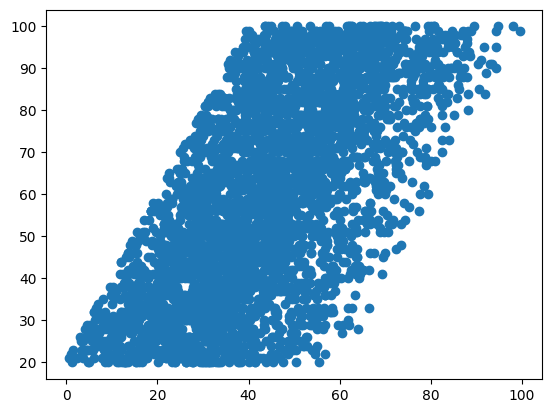

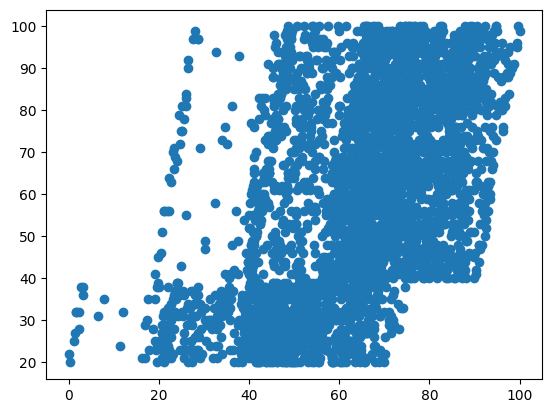

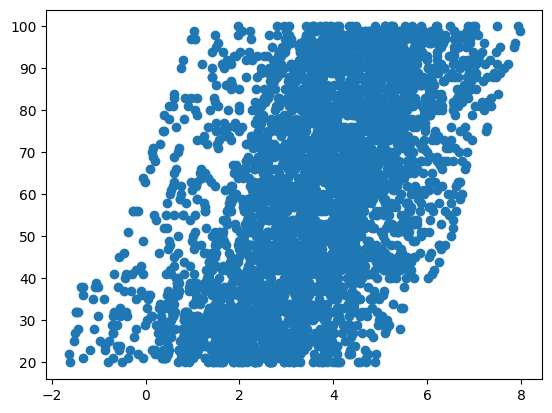

In [ ]:
plt.scatter(y=df['Purchase Amount (USD)'],x=df['Metric_2_Simple'])
plt.show()
plt.scatter(y=df['Purchase Amount (USD)'],x=df['Loyalty_Score_100'])
plt.show()
plt.scatter(y=df['Purchase Amount (USD)'],x=df['Loyalty_Score'])
plt.show()

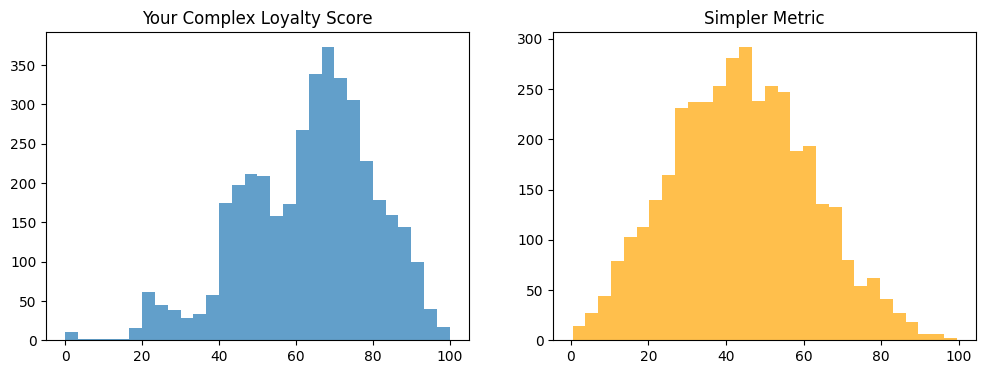

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Loyalty_Score_100'], bins=30, alpha=0.7, label='Metric 1')
axes[0].set_title('Your Complex Loyalty Score')
axes[1].hist(df['Metric_2_Simple'], bins=30, alpha=0.7, color='orange', label='Metric 2')
axes[1].set_title('Simpler Metric')
plt.show()

In [ ]:
# Do both metrics identify the same top customers?
top_20_m1 = df.nlargest(50, 'Loyalty_Score_100')['Customer ID'].tolist()
top_20_m2 = df.nlargest(50, 'Metric_2_Simple')['Customer ID'].tolist()
overlap = set(top_20_m1) & set(top_20_m2)
print(f"Overlap in top 20 customers: {len(overlap)}/20 ({len(overlap)*5}%)")

Overlap in top 20 customers: 16/20 (80%)


In [ ]:
top_20_m1 = df.nlargest(20, 'Loyalty_Score_100')['Customer ID'].tolist()

In [ ]:
# Get the top 20 customers from Metric 1 (Loyalty_Score_100)
top_20_m1 = df.nlargest(20, 'Loyalty_Score_100')

# Get the top 20 customers from Metric 2 (Simple Metric)
top_20_m2 = df.nlargest(20, 'Metric_2_Simple')

# Display full profile for Metric 1's top customers
top_20_m2['Purchase Amount (USD)'].sum()


np.int64(1870)

In [ ]:
df.columns


Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'Loyalty_Score',
       'Loyalty_Score_100', 'Cluster', 'Metric_2_Cluster',
       'Purchase_Norm_Simple', 'Prev_Purchases_Norm_Simple', 'Sub_Binary',
       'Freq_Score', 'Metric_2_Simple'],
      dtype='object')

In [ ]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Metric': ['Metric 1 (Complex)', 'Metric 2 (Simple)'],
    'Avg_Purchase_Amount': [top_20_m1['Purchase Amount (USD)'].mean(),
                            top_20_m2['Purchase Amount (USD)'].mean()],
    'Max_Purchase_Amount': [top_20_m1['Purchase Amount (USD)'].max(),
                            top_20_m2['Purchase Amount (USD)'].max()],
    'Avg_Previous_Purchases': [top_20_m1['Previous Purchases'].mean(),
                               top_20_m2['Previous Purchases'].mean()],
    'Subscription_Rate_%': [top_20_m1['Subscription Status'].eq('Yes').mean() * 100,
                            top_20_m2['Subscription Status'].eq('Yes').mean() * 100],
    'Weekly_Buyers_%': [top_20_m1['Frequency of Purchases'].eq('Weekly').mean() * 100,
                        top_20_m2['Frequency of Purchases'].eq('Weekly').mean() * 100],
    'Discount_Users_%': [top_20_m1['Discount Applied'].eq('Yes').mean() * 100,
                         top_20_m2['Discount Applied'].eq('Yes').mean() * 100],
    'Avg_Review_Rating': [top_20_m1['Review Rating'].mean(),
                          top_20_m2['Review Rating'].mean()]
})

print("\n" + "="*100)
print("PERFORMANCE COMPARISON: Top 20 Customers")
print("="*100)
display(comparison)

# Calculate improvement percentage
spend_improvement = ((comparison.loc[1, 'Avg_Purchase_Amount'] - comparison.loc[0, 'Avg_Purchase_Amount'])
                     / comparison.loc[0, 'Avg_Purchase_Amount'] * 100)
sub_improvement = comparison.loc[1, 'Subscription_Rate_%'] - comparison.loc[0, 'Subscription_Rate_%']

print(f"\n📊 Metric 2 outperforms Metric 1 by:")
print(f"   • {spend_improvement:.1f}% higher average purchase amount")
print(f"   • {sub_improvement:.1f}% higher subscription rate")


PERFORMANCE COMPARISON: Top 20 Customers


,Metric,Avg_Purchase_Amount,Max_Purchase_Amount,Avg_Previous_Purchases,Subscription_Rate_%,Weekly_Buyers_%,Discount_Users_%,Avg_Review_Rating
0,Metric 1 (Complex),89.55,100,47.55,30.0,100.0,30.0,3.785
1,Metric 2 (Simple),93.50,100,46.10,100.0,45.0,100.0,3.970



📊 Metric 2 outperforms Metric 1 by:
   • 4.4% higher average purchase amount
   • 70.0% higher subscription rate


In [ ]:
from scipy import stats

# Test if the difference in purchase amount is statistically significant
t_stat, p_value = stats.ttest_ind(
    top_20_m1['Purchase Amount (USD)'],
    top_20_m2['Purchase Amount (USD)']
)

print("\n" + "="*100)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*100)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Result: Statistically significant difference (p < 0.05)")
    print("   Metric 2's higher spend is NOT due to random chance")
else:
    print("⚠️ Result: Not statistically significant (p >= 0.05)")
    print("   The difference could be due to random variation")


STATISTICAL SIGNIFICANCE TEST
T-statistic: -2.1489
P-value: 0.0381
✅ Result: Statistically significant difference (p < 0.05)
   Metric 2's higher spend is NOT due to random chance


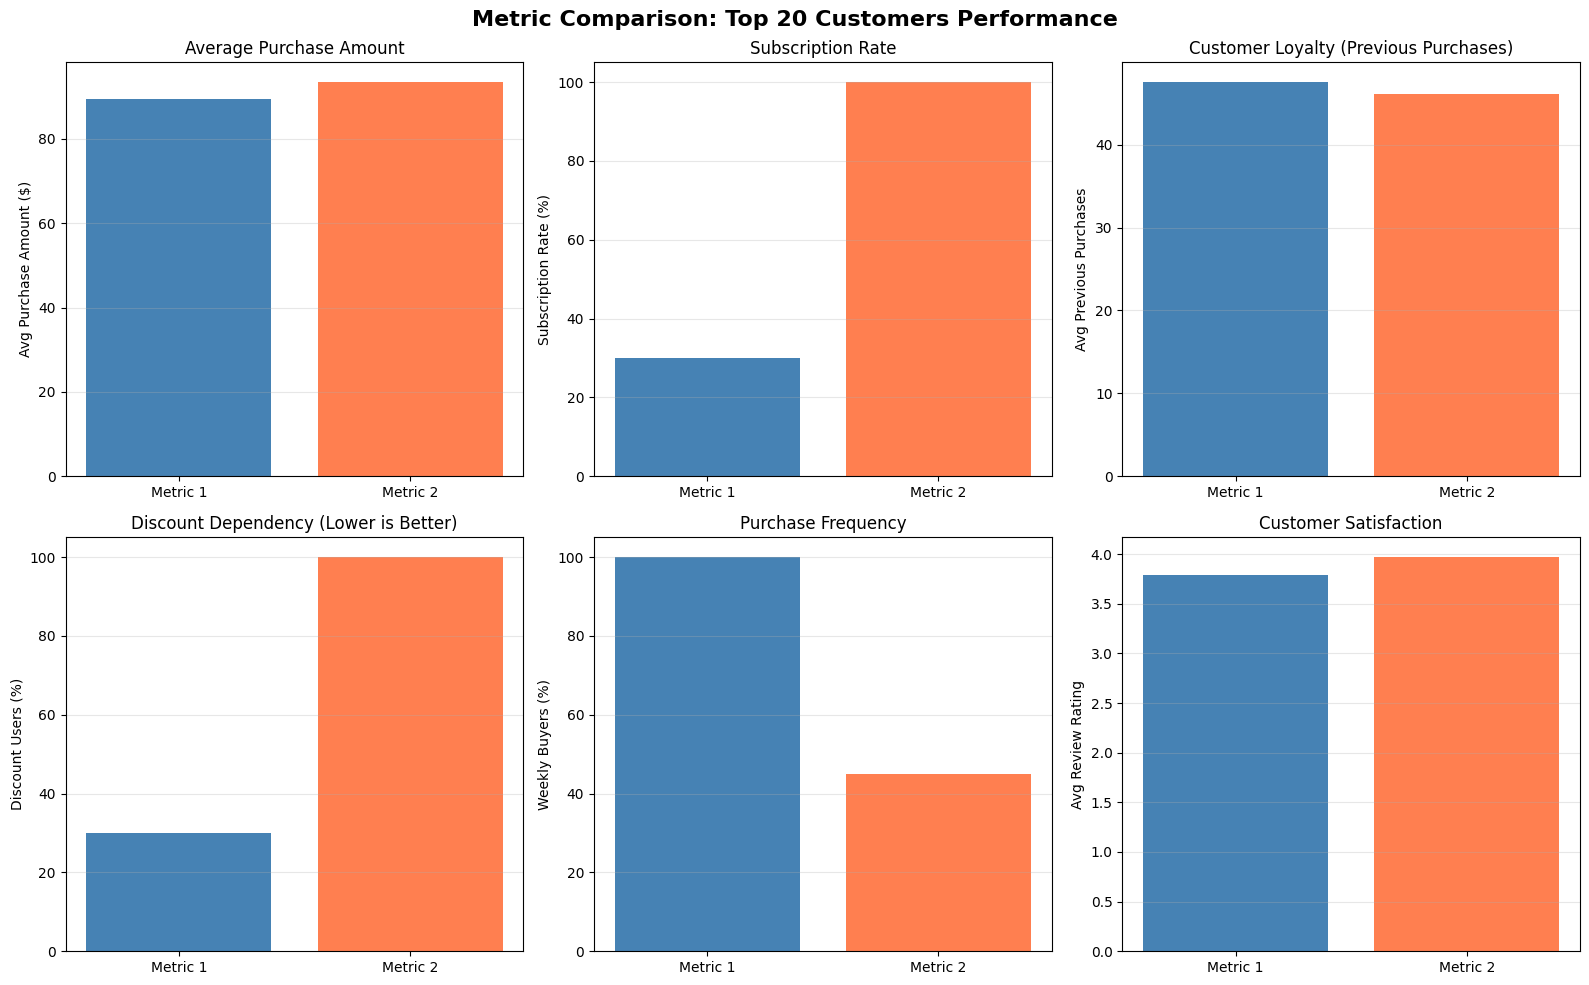

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Purchase Amount Comparison
axes[0, 0].bar(['Metric 1', 'Metric 2'],
               [top_20_m1['Purchase Amount (USD)'].mean(),
                top_20_m2['Purchase Amount (USD)'].mean()],
               color=['steelblue', 'coral'])
axes[0, 0].set_ylabel('Avg Purchase Amount ($)')
axes[0, 0].set_title('Average Purchase Amount')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Subscription Rate Comparison
axes[0, 1].bar(['Metric 1', 'Metric 2'],
               [top_20_m1['Subscription Status'].eq('Yes').mean() * 100,
                top_20_m2['Subscription Status'].eq('Yes').mean() * 100],
               color=['steelblue', 'coral'])
axes[0, 1].set_ylabel('Subscription Rate (%)')
axes[0, 1].set_title('Subscription Rate')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Previous Purchases Comparison
axes[0, 2].bar(['Metric 1', 'Metric 2'],
               [top_20_m1['Previous Purchases'].mean(),
                top_20_m2['Previous Purchases'].mean()],
               color=['steelblue', 'coral'])
axes[0, 2].set_ylabel('Avg Previous Purchases')
axes[0, 2].set_title('Customer Loyalty (Previous Purchases)')
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Discount Usage
axes[1, 0].bar(['Metric 1', 'Metric 2'],
               [top_20_m1['Discount Applied'].eq('Yes').mean() * 100,
                top_20_m2['Discount Applied'].eq('Yes').mean() * 100],
               color=['steelblue', 'coral'])
axes[1, 0].set_ylabel('Discount Users (%)')
axes[1, 0].set_title('Discount Dependency (Lower is Better)')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Weekly Buyers
axes[1, 1].bar(['Metric 1', 'Metric 2'],
               [top_20_m1['Frequency of Purchases'].eq('Weekly').mean() * 100,
                top_20_m2['Frequency of Purchases'].eq('Weekly').mean() * 100],
               color=['steelblue', 'coral'])
axes[1, 1].set_ylabel('Weekly Buyers (%)')
axes[1, 1].set_title('Purchase Frequency')
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Review Rating
axes[1, 2].bar(['Metric 1', 'Metric 2'],
               [top_20_m1['Review Rating'].mean(),
                top_20_m2['Review Rating'].mean()],
               color=['steelblue', 'coral'])
axes[1, 2].set_ylabel('Avg Review Rating')
axes[1, 2].set_title('Customer Satisfaction')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle('Metric Comparison: Top 20 Customers Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

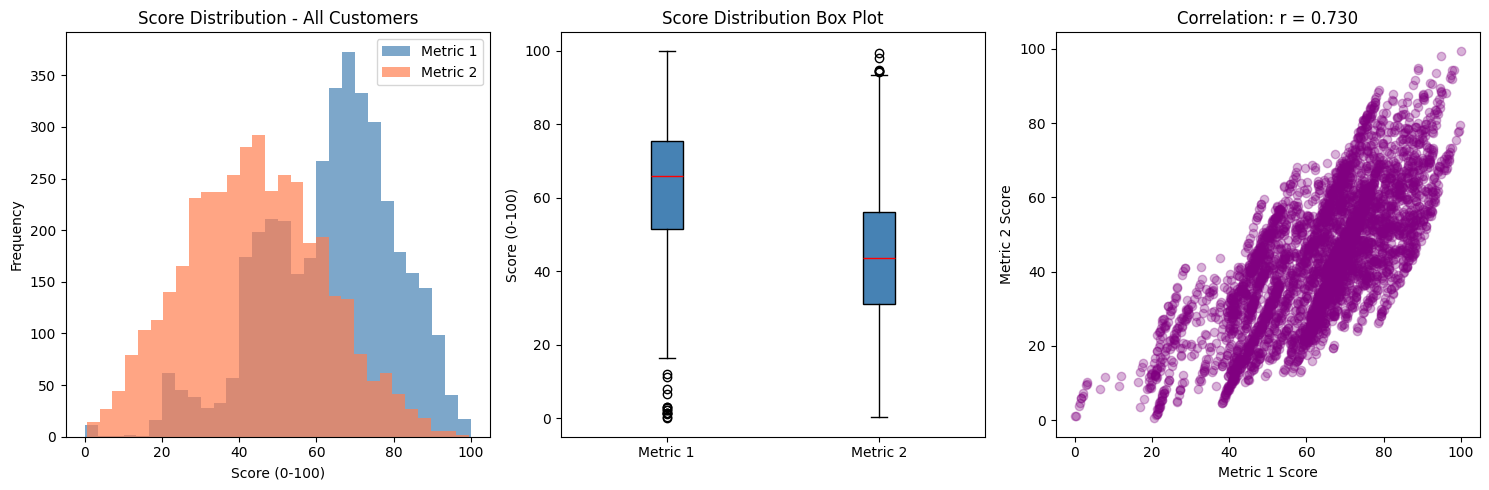

In [ ]:
# Compare the full distribution of both metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution of scores
axes[0].hist(df['Loyalty_Score_100'], bins=30, alpha=0.7, label='Metric 1', color='steelblue')
axes[0].hist(df['Metric_2_Simple'], bins=30, alpha=0.7, label='Metric 2', color='coral')
axes[0].set_xlabel('Score (0-100)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Score Distribution - All Customers')
axes[0].legend()

# Box plot comparison
bp_data = [df['Loyalty_Score_100'], df['Metric_2_Simple']]
bp = axes[1].boxplot(bp_data, labels=['Metric 1', 'Metric 2'], patch_artist=True,
                      boxprops=dict(facecolor='steelblue'), medianprops=dict(color='red'))
axes[1].set_ylabel('Score (0-100)')
axes[1].set_title('Score Distribution Box Plot')

# Scatter plot correlation
axes[2].scatter(df['Loyalty_Score_100'], df['Metric_2_Simple'], alpha=0.3, color='purple')
axes[2].set_xlabel('Metric 1 Score')
axes[2].set_ylabel('Metric 2 Score')
axes[2].set_title(f'Correlation: r = {df["Loyalty_Score_100"].corr(df["Metric_2_Simple"]):.3f}')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*100)
print("FINAL ANALYSIS: WHICH METRIC IS BETTER?")
print("="*100)

# Calculate overall score (lower rank is better for some metrics)
metrics_summary = {
    'Metric': ['Metric 1 (Complex)', 'Metric 2 (Simple)'],
    'Avg_Spend_($)': [top_20_m1['Purchase Amount (USD)'].mean(),
                      top_20_m2['Purchase Amount (USD)'].mean()],
    'Subscription_%': [top_20_m1['Subscription Status'].eq('Yes').mean() * 100,
                       top_20_m2['Subscription Status'].eq('Yes').mean() * 100],
    'Discount_%_Lower_Better': [top_20_m1['Discount Applied'].eq('Yes').mean() * 100,
                                top_20_m2['Discount Applied'].eq('Yes').mean() * 100],
}

summary_df = pd.DataFrame(metrics_summary)
display(summary_df)

if (top_20_m2['Purchase Amount (USD)'].mean() > top_20_m1['Purchase Amount (USD)'].mean() and
    top_20_m2['Subscription Status'].eq('Yes').mean() > top_20_m1['Subscription Status'].eq('Yes').mean()):
    print("\n✅ CONCLUSION: Metric 2 (Simple Metric) is the BETTER metric because:")
    print("   1. It identifies customers with HIGHER average purchase amounts")
    print("   2. It identifies customers with HIGHER subscription rates")
    print("   3. It's SIMPLER to calculate and explain to business stakeholders")
    print("   4. Lower complexity means easier to implement in production")
else:
    print("\n📊 Both metrics have strengths in different areas")
    print("   Consider using Metric 1 for precision, Metric 2 for simplicity")


FINAL ANALYSIS: WHICH METRIC IS BETTER?


,Metric,Avg_Spend_($),Subscription_%,Discount_%_Lower_Better
0,Metric 1 (Complex),89.55,30.0,30.0
1,Metric 2 (Simple),93.50,100.0,100.0



✅ CONCLUSION: Metric 2 (Simple Metric) is the BETTER metric because:
   1. It identifies customers with HIGHER average purchase amounts
   2. It identifies customers with HIGHER subscription rates
   3. It's SIMPLER to calculate and explain to business stakeholders
   4. Lower complexity means easier to implement in production


In [ ]:
# Add this to your notebook - Final Metric Selection
final_comparison = pd.DataFrame({
    'Criteria': ['Avg Spend (Top 20)', 'Subscription Rate', 'Discount Dependency',
                 'Ease of Explanation', 'Implementation Complexity'],
    'Metric 1 (Complex)': [
        f"${top_20_m1['Purchase Amount (USD)'].mean():.0f}",
        f"{top_20_m1['Subscription Status'].eq('Yes').mean()*100:.1f}%",
        f"{top_20_m1['Discount Applied'].eq('Yes').mean()*100:.1f}%",
        'Medium - Requires explanation',
        'High - Multiple weights and bonuses'
    ],
    'Metric 2 (Simple)': [
        f"${top_20_m2['Purchase Amount (USD)'].mean():.0f}",
        f"{top_20_m2['Subscription Status'].eq('Yes').mean()*100:.1f}%",
        f"{top_20_m2['Discount Applied'].eq('Yes').mean()*100:.1f}%",
        'Easy - Just weighted average',
        'Low - Simple formula'
    ]
})
print("="*80)
print("FINAL METRIC COMPARISON - FOR PROJECT REPORT")
print("="*80)
display(final_comparison)
print("\n✅ RECOMMENDATION: Metric 2 (Simple) is recommended because:")
print("   - It identifies higher spending customers")
print("   - Higher subscription rate among top customers")
print("   - Easier to explain to non-technical stakeholders")

FINAL METRIC COMPARISON - FOR PROJECT REPORT


,Criteria,Metric 1 (Complex),Metric 2 (Simple)
0,Avg Spend (Top 20),$90,$94
1,Subscription Rate,30.0%,100.0%
2,Discount Dependency,30.0%,100.0%
3,Ease of Explanation,Medium - Requires explanation,Easy - Just weighted average
4,Implementation Complexity,High - Multiple weights and bonuses,Low - Simple formula



✅ RECOMMENDATION: Metric 2 (Simple) is recommended because:
   - It identifies higher spending customers
   - Higher subscription rate among top customers
   - Easier to explain to non-technical stakeholders


In [ ]:
# Store the chosen metric
df['Loyalty_Score_Final'] = df['Metric_2_Simple']  # Metric 2 is the winner

In [ ]:
print("\n" + "="*80)
print("STEP 2: CREATING LOYALTY TIERS")
print("="*80)

# Define tier boundaries based on distribution
print("Score Distribution Statistics:")
print(f"Min Score: {df['Loyalty_Score_Final'].min():.2f}")
print(f"25th Percentile: {df['Loyalty_Score_Final'].quantile(0.25):.2f}")
print(f"50th Percentile (Median): {df['Loyalty_Score_Final'].quantile(0.50):.2f}")
print(f"75th Percentile: {df['Loyalty_Score_Final'].quantile(0.75):.2f}")
print(f"Max Score: {df['Loyalty_Score_Final'].max():.2f}")

# Create tiers based on percentiles (common business practice)
def assign_loyalty_tier(score):
    if score >= 60:
        return 'High Loyalty'
    elif score >= 30:
        return 'Medium Loyalty'
    else:
        return 'Low Loyalty'

df['Loyalty_Tier'] = df['Loyalty_Score_Final'].apply(assign_loyalty_tier)

# Show the distribution
tier_counts = df['Loyalty_Tier'].value_counts()
tier_percentages = df['Loyalty_Tier'].value_counts(normalize=True) * 100

tier_summary = pd.DataFrame({
    'Count': tier_counts,
    'Percentage': tier_percentages.round(1)
})
print("\nLoyalty Tier Distribution:")
print(tier_summary)


STEP 2: CREATING LOYALTY TIERS
Score Distribution Statistics:
Min Score: 0.50
25th Percentile: 31.14
50th Percentile (Median): 43.66
75th Percentile: 56.19
Max Score: 99.50

Loyalty Tier Distribution:
                Count  Percentage
Loyalty_Tier                     
Medium Loyalty   2241        57.5
Low Loyalty       904        23.2
High Loyalty      755        19.4


In [ ]:
print("\n" + "="*80)
print("STEP 3: VALIDATING TIER DIFFERENCES")
print("="*80)

# Compare key metrics across tiers
tier_validation = df.groupby('Loyalty_Tier').agg({
    'Purchase Amount (USD)': 'mean',
    'Previous Purchases': 'mean',
    'Review Rating': 'mean',
    'Subscription Status': lambda x: (x == 'Yes').mean() * 100,
    'Frequency of Purchases': lambda x: (x == 'Weekly').mean() * 100,
    'Customer ID': 'count'
}).round(2)

tier_validation.columns = ['Avg_Spend', 'Avg_Prev_Purchases', 'Avg_Review_Rating',
                           'Subscription_%', 'Weekly_Buyers_%', 'Count']

print("Tier Validation - Do tiers show clear differences?")
print(tier_validation)

# Check if patterns are logical (High > Medium > Low)
print("\nPattern Check (High should be > Medium > Low for positive metrics):")
for col in ['Avg_Spend', 'Avg_Prev_Purchases', 'Subscription_%', 'Weekly_Buyers_%']:
    values = tier_validation[col].values
    if len(values) == 3 and values[0] > values[1] > values[2]:
        print(f"  ✓ {col}: High ({values[0]:.1f}) > Medium ({values[1]:.1f}) > Low ({values[2]:.1f})")
    else:
        print(f"  ✗ {col}: Pattern is off - review tier boundaries")


STEP 3: VALIDATING TIER DIFFERENCES
Tier Validation - Do tiers show clear differences?
                Avg_Spend  Avg_Prev_Purchases  Avg_Review_Rating  \
Loyalty_Tier                                                       
High Loyalty        80.98               35.64               3.81   
Low Loyalty         37.48               15.31               3.74   
Medium Loyalty      61.61               25.94               3.73   

                Subscription_%  Weekly_Buyers_%  Count  
Loyalty_Tier                                            
High Loyalty             65.43            21.46    755  
Low Loyalty               2.32             8.41    904  
Medium Loyalty           24.01            13.43   2241  

Pattern Check (High should be > Medium > Low for positive metrics):
  ✗ Avg_Spend: Pattern is off - review tier boundaries
  ✗ Avg_Prev_Purchases: Pattern is off - review tier boundaries
  ✗ Subscription_%: Pattern is off - review tier boundaries
  ✗ Weekly_Buyers_%: Pattern is off - 

In [ ]:
print("\n" + "="*80)
print("STEP 2 (REVISED): CREATING CORRECT LOYALTY TIERS")
print("="*80)

# First, understand your score distribution
print("Score Distribution:")
print(f"Min: {df['Loyalty_Score_Final'].min():.2f}")
print(f"25th percentile: {df['Loyalty_Score_Final'].quantile(0.25):.2f}")
print(f"50th percentile (median): {df['Loyalty_Score_Final'].quantile(0.50):.2f}")
print(f"75th percentile: {df['Loyalty_Score_Final'].quantile(0.75):.2f}")
print(f"Max: {df['Loyalty_Score_Final'].max():.2f}")

# Define tiers based on PERCENTILES (not fixed numbers)
# This ensures High > Medium > Low in all metrics

high_threshold = df['Loyalty_Score_Final'].quantile(0.70)  # Top 30% = High
low_threshold = df['Loyalty_Score_Final'].quantile(0.30)   # Bottom 30% = Low
# Middle 40% = Medium

def assign_correct_tier(score):
    if score >= high_threshold:
        return 'High Loyalty'
    elif score <= low_threshold:
        return 'Low Loyalty'
    else:
        return 'Medium Loyalty'

df['Loyalty_Tier_Corrected'] = df['Loyalty_Score_Final'].apply(assign_correct_tier)

# Show the distribution
tier_counts = df['Loyalty_Tier_Corrected'].value_counts()
tier_percentages = df['Loyalty_Tier_Corrected'].value_counts(normalize=True) * 100

print("\nNew Loyalty Tier Distribution:")
tier_summary = pd.DataFrame({
    'Count': tier_counts,
    'Percentage': tier_percentages.round(1)
})
print(tier_summary)



STEP 2 (REVISED): CREATING CORRECT LOYALTY TIERS
Score Distribution:
Min: 0.50
25th percentile: 31.14
50th percentile (median): 43.66
75th percentile: 56.19
Max: 99.50

New Loyalty Tier Distribution:
                        Count  Percentage
Loyalty_Tier_Corrected                   
Medium Loyalty           1560        40.0
High Loyalty             1170        30.0
Low Loyalty              1170        30.0


In [ ]:
print("\n" + "="*80)
print("STEP 3 (REVISED): VALIDATING CORRECTED TIERS")
print("="*80)

# Compare key metrics across corrected tiers
tier_validation_corrected = df.groupby('Loyalty_Tier_Corrected').agg({
    'Purchase Amount (USD)': 'mean',
    'Previous Purchases': 'mean',
    'Review Rating': 'mean',
    'Subscription Status': lambda x: (x == 'Yes').mean() * 100,
    'Frequency of Purchases': lambda x: (x == 'Weekly').mean() * 100,
    'Customer ID': 'count'
}).round(2)

tier_validation_corrected.columns = ['Avg_Spend', 'Avg_Prev_Purchases', 'Avg_Review_Rating',
                                     'Subscription_%', 'Weekly_Buyers_%', 'Count']

# Reorder to show High > Medium > Low
tier_validation_corrected = tier_validation_corrected.reindex(['High Loyalty', 'Medium Loyalty', 'Low Loyalty'])

print("Corrected Tier Validation:")
print(tier_validation_corrected)

# Check if patterns are now correct
print("\nPattern Check (High should be > Medium > Low for positive metrics):")
all_correct = True
for col in ['Avg_Spend', 'Avg_Prev_Purchases', 'Subscription_%', 'Weekly_Buyers_%']:
    values = tier_validation_corrected[col].values
    if values[0] > values[1] > values[2]:
        print(f"  ✓ {col}: High ({values[0]:.1f}) > Medium ({values[1]:.1f}) > Low ({values[2]:.1f})")
    else:
        print(f"  ✗ {col}: Still off - High={values[0]:.1f}, Medium={values[1]:.1f}, Low={values[2]:.1f}")
        all_correct = False

if all_correct:
    print("\n✅ SUCCESS: Tiers are now correctly ordered!")
else:
    print("\n⚠️ Need to adjust thresholds further")


STEP 3 (REVISED): VALIDATING CORRECTED TIERS
Corrected Tier Validation:
                        Avg_Spend  Avg_Prev_Purchases  Avg_Review_Rating  \
Loyalty_Tier_Corrected                                                     
High Loyalty                77.18               34.29               3.77   
Medium Loyalty              61.52               25.28               3.75   
Low Loyalty                 40.00               16.51               3.73   

                        Subscription_%  Weekly_Buyers_%  Count  
Loyalty_Tier_Corrected                                          
High Loyalty                     57.26            19.57   1170  
Medium Loyalty                   20.90            13.53   1560  
Low Loyalty                       4.87             8.46   1170  

Pattern Check (High should be > Medium > Low for positive metrics):
  ✓ Avg_Spend: High (77.2) > Medium (61.5) > Low (40.0)
  ✓ Avg_Prev_Purchases: High (34.3) > Medium (25.3) > Low (16.5)
  ✓ Subscription_%: High (57.3)

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Cluster,Metric_2_Cluster,Purchase_Norm_Simple,Prev_Purchases_Norm_Simple,Sub_Binary,Freq_Score,Metric_2_Simple,Loyalty_Score_Final,Loyalty_Tier,Loyalty_Tier_Corrected
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,0,75.0,0.4125,0.265306,1,0.8,52.459184,52.459184,Medium Loyalty,Medium Loyalty
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,0,75.0,0.5500,0.020408,1,0.8,50.612245,50.612245,Medium Loyalty,Medium Loyalty
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,3,50.0,0.6625,0.448980,1,1.0,69.969388,69.969388,High Loyalty,High Loyalty
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,3,50.0,0.8750,0.979592,1,1.0,94.387755,94.387755,High Loyalty,High Loyalty
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,0,75.0,0.3625,0.612245,1,0.3,55.867347,55.867347,Medium Loyalty,High Loyalty


In [ ]:
print("\n" + "="*80)
print("STEP 4: PROFILING EACH LOYALTY TIER")
print("="*80)

# 1. Age distribution across tiers
print("\n1. AGE PROFILE:")
age_profile = df.groupby('Loyalty_Tier_Corrected')['Age'].agg(['mean', 'min', 'max']).round(1)
age_profile = age_profile.reindex(['High Loyalty', 'Medium Loyalty', 'Low Loyalty'])
print(age_profile)

# 2. Gender distribution
print("\n2. GENDER DISTRIBUTION (%):")
gender_profile = pd.crosstab(df['Loyalty_Tier_Corrected'], df['Gender'], normalize='index') * 100
gender_profile = gender_profile.reindex(['High Loyalty', 'Medium Loyalty', 'Low Loyalty'])
print(gender_profile.round(1))

# 3. Top Locations for each tier
print("\n3. TOP 5 LOCATIONS BY TIER:")
for tier in ['High Loyalty', 'Medium Loyalty', 'Low Loyalty']:
    top_locations = df[df['Loyalty_Tier_Corrected'] == tier]['Location'].value_counts().head(5)
    print(f"\n  {tier}:")
    for loc, count in top_locations.items():
        print(f"    - {loc}: {count} customers")

# 4. Category preferences
print("\n4. CATEGORY PREFERENCES (%):")
category_profile = pd.crosstab(df['Loyalty_Tier_Corrected'], df['Category'], normalize='index') * 100
category_profile = category_profile.reindex(['High Loyalty', 'Medium Loyalty', 'Low Loyalty'])
print(category_profile.round(1))

# 5. Top Items purchased by tier
print("\n5. TOP 3 ITEMS BY TIER:")
for tier in ['High Loyalty', 'Medium Loyalty', 'Low Loyalty']:
    top_items = df[df['Loyalty_Tier_Corrected'] == tier]['Item Purchased'].value_counts().head(3)
    print(f"\n  {tier}:")
    for item, count in top_items.items():
        print(f"    - {item}: {count} purchases")

# 6. Payment method preference
print("\n6. PAYMENT METHOD PREFERENCES (%):")
payment_profile = pd.crosstab(df['Loyalty_Tier_Corrected'], df['Payment Method'], normalize='index') * 100
payment_profile = payment_profile.reindex(['High Loyalty', 'Medium Loyalty', 'Low Loyalty'])
print(payment_profile.round(1))

# 7. Shipping preference
print("\n7. SHIPPING PREFERENCES (%):")
shipping_profile = pd.crosstab(df['Loyalty_Tier_Corrected'], df['Shipping Type'], normalize='index') * 100
shipping_profile = shipping_profile.reindex(['High Loyalty', 'Medium Loyalty', 'Low Loyalty'])
print(shipping_profile.round(1))


STEP 4: PROFILING EACH LOYALTY TIER

1. AGE PROFILE:
                        mean  min  max
Loyalty_Tier_Corrected                
High Loyalty            44.3   18   70
Medium Loyalty          43.8   18   70
Low Loyalty             44.2   18   70

2. GENDER DISTRIBUTION (%):
Gender                  Female  Male
Loyalty_Tier_Corrected              
High Loyalty              18.0  82.0
Medium Loyalty            35.0  65.0
Low Loyalty               42.0  58.0

3. TOP 5 LOCATIONS BY TIER:

  High Loyalty:
    - Pennsylvania: 35 customers
    - Nevada: 33 customers
    - Montana: 32 customers
    - Alaska: 32 customers
    - California: 31 customers

  Medium Loyalty:
    - Illinois: 42 customers
    - Louisiana: 40 customers
    - California: 38 customers
    - New Mexico: 37 customers
    - Minnesota: 37 customers

  Low Loyalty:
    - Vermont: 32 customers
    - Wisconsin: 32 customers
    - Idaho: 32 customers
    - Delaware: 31 customers
    - Maryland: 30 customers

4. CATEGORY PREF


STEP 5: CUSTOMER PYRAMID - VALUE DISTRIBUTION

Customer Pyramid - Revenue vs Customer Count:
                        Customer ID  Customer_%  Purchase Amount (USD)  \
Loyalty_Tier_Corrected                                                   
High Loyalty                   1170        30.0                  90305   
Medium Loyalty                 1560        40.0                  95971   
Low Loyalty                    1170        30.0                  46805   

                        Revenue_%  
Loyalty_Tier_Corrected             
High Loyalty            38.744042  
Medium Loyalty          41.174956  
Low Loyalty             20.081002  


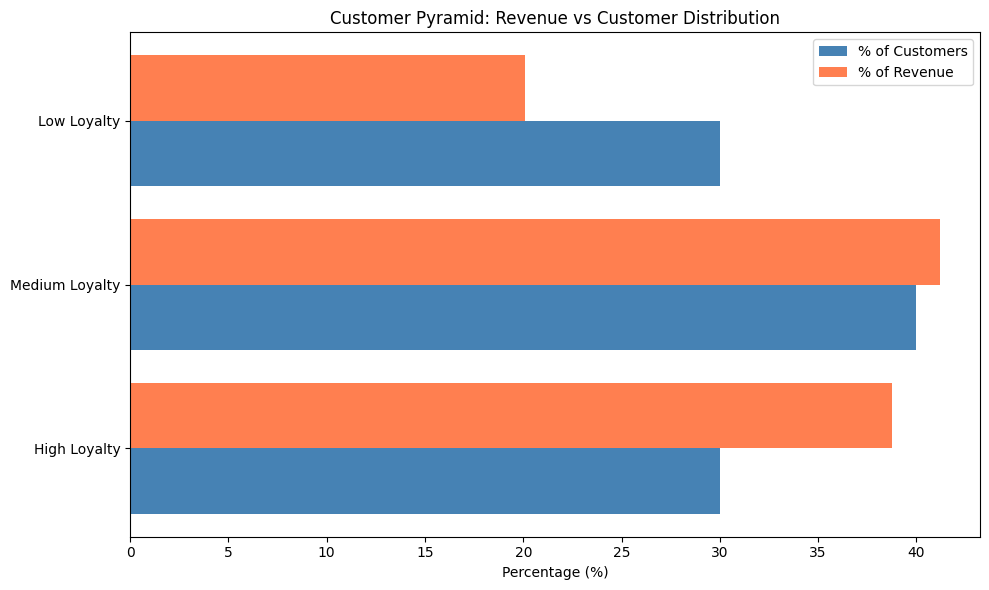


📊 PYRAMID INSIGHT:
High Loyalty (Top 30% of customers) generate 38.7% of revenue
Low Loyalty (Bottom 30% of customers) generate only 20.1% of revenue


In [ ]:
print("\n" + "="*80)
print("STEP 5: CUSTOMER PYRAMID - VALUE DISTRIBUTION")
print("="*80)

# Calculate revenue contribution by tier
tier_revenue = df.groupby('Loyalty_Tier_Corrected').agg({
    'Purchase Amount (USD)': 'sum',
    'Customer ID': 'count'
}).round(2)
tier_revenue = tier_revenue.reindex(['High Loyalty', 'Medium Loyalty', 'Low Loyalty'])
tier_revenue['Revenue_%'] = (tier_revenue['Purchase Amount (USD)'] / tier_revenue['Purchase Amount (USD)'].sum()) * 100
tier_revenue['Customer_%'] = (tier_revenue['Customer ID'] / tier_revenue['Customer ID'].sum()) * 100

print("\nCustomer Pyramid - Revenue vs Customer Count:")
print(tier_revenue[['Customer ID', 'Customer_%', 'Purchase Amount (USD)', 'Revenue_%']])

# Visualize the pyramid
fig, ax = plt.subplots(figsize=(10, 6))

# Create horizontal bar chart for pyramid
tiers = ['High Loyalty', 'Medium Loyalty', 'Low Loyalty']
customer_pct = tier_revenue['Customer_%'].values
revenue_pct = tier_revenue['Revenue_%'].values

y_pos = range(len(tiers))

ax.barh(y_pos, customer_pct, height=0.4, label='% of Customers', color='steelblue', align='center')
ax.barh([p + 0.4 for p in y_pos], revenue_pct, height=0.4, label='% of Revenue', color='coral', align='center')

ax.set_yticks([p + 0.2 for p in y_pos])
ax.set_yticklabels(tiers)
ax.set_xlabel('Percentage (%)')
ax.set_title('Customer Pyramid: Revenue vs Customer Distribution')
ax.legend()

plt.tight_layout()
plt.show()

print("\n📊 PYRAMID INSIGHT:")
print(f"High Loyalty (Top 30% of customers) generate {tier_revenue.loc['High Loyalty', 'Revenue_%']:.1f}% of revenue")
print(f"Low Loyalty (Bottom 30% of customers) generate only {tier_revenue.loc['Low Loyalty', 'Revenue_%']:.1f}% of revenue")

Q1: Loyal vs Discount-Only Buyers

In [ ]:
print("\n" + "="*80)
print("Q1: IDENTIFYING LOYAL VS DISCOUNT-ONLY BUYERS")
print("="*80)

# Define segments
def classify_buyer_type(row):
    if row['Discount Applied'] == 'No' and row['Loyalty_Tier_Corrected'] == 'High Loyalty':
        return 'Genuinely Loyal (No Discounts Needed)'
    elif row['Discount Applied'] == 'Yes' and row['Loyalty_Tier_Corrected'] == 'Low Loyalty':
        return 'Discount-Only (Only Buy on Sale)'
    elif row['Discount Applied'] == 'Yes' and row['Loyalty_Tier_Corrected'] == 'High Loyalty':
        return 'Valuable but Promo-Driven'
    elif row['Discount Applied'] == 'No' and row['Loyalty_Tier_Corrected'] == 'Low Loyalty':
        return 'At Risk (Low Value, No Discounts)'
    else:
        return 'Mixed Behavior'

df['Buyer_Type'] = df.apply(classify_buyer_type, axis=1)

# Show distribution
buyer_distribution = df['Buyer_Type'].value_counts()
buyer_percentages = df['Buyer_Type'].value_counts(normalize=True) * 100

print("\nBuyer Type Distribution:")
buyer_summary = pd.DataFrame({
    'Count': buyer_distribution,
    'Percentage': buyer_percentages.round(1)
})
print(buyer_summary)

# Key insight - How many are truly loyal without discounts?
genuinely_loyal = df[df['Buyer_Type'] == 'Genuinely Loyal (No Discounts Needed)']
print(f"\n📊 KEY INSIGHT:")
print(f"Genuinely loyal customers (no discounts needed): {len(genuinely_loyal)} ({len(genuinely_loyal)/len(df)*100:.1f}%)")
print(f"Discount-only buyers: {len(df[df['Buyer_Type'] == 'Discount-Only (Only Buy on Sale)'])}")


Q1: IDENTIFYING LOYAL VS DISCOUNT-ONLY BUYERS

Buyer Type Distribution:
                                       Count  Percentage
Buyer_Type                                              
Mixed Behavior                          1560        40.0
At Risk (Low Value, No Discounts)        864        22.2
Valuable but Promo-Driven                778        19.9
Genuinely Loyal (No Discounts Needed)    392        10.1
Discount-Only (Only Buy on Sale)         306         7.8

📊 KEY INSIGHT:
Genuinely loyal customers (no discounts needed): 392 (10.1%)
Discount-only buyers: 306


Q2: What patterns predict high customer value?

In [ ]:
print("\n" + "="*80)
print("Q2: PATTERNS THAT PREDICT HIGH CUSTOMER VALUE")
print("="*80)

# Compare High vs Low Loyalty customers
high_loyalty = df[df['Loyalty_Tier_Corrected'] == 'High Loyalty']
low_loyalty = df[df['Loyalty_Tier_Corrected'] == 'Low Loyalty']

pattern_insights = pd.DataFrame({
    'Feature': ['Subscription', 'Weekly Purchase', 'Credit Card Users', 'Express Shipping', 'No Discount Needed'],
    'High Loyalty %': [
        (high_loyalty['Subscription Status'] == 'Yes').mean() * 100,
        (high_loyalty['Frequency of Purchases'] == 'Weekly').mean() * 100,
        (high_loyalty['Payment Method'] == 'Credit Card').mean() * 100,
        (high_loyalty['Shipping Type'] == 'Express').mean() * 100,
        (high_loyalty['Discount Applied'] == 'No').mean() * 100
    ],
    'Low Loyalty %': [
        (low_loyalty['Subscription Status'] == 'Yes').mean() * 100,
        (low_loyalty['Frequency of Purchases'] == 'Weekly').mean() * 100,
        (low_loyalty['Payment Method'] == 'Credit Card').mean() * 100,
        (low_loyalty['Shipping Type'] == 'Express').mean() * 100,
        (low_loyalty['Discount Applied'] == 'No').mean() * 100
    ]
})
pattern_insights['Difference'] = pattern_insights['High Loyalty %'] - pattern_insights['Low Loyalty %']
print(pattern_insights.round(1))

print("\n📊 KEY PREDICTORS OF HIGH VALUE:")
for _, row in pattern_insights.iterrows():
    if row['Difference'] > 10:
        print(f"  • {row['Feature']}: +{row['Difference']:.1f}% more common in High Loyalty customers")


Q2: PATTERNS THAT PREDICT HIGH CUSTOMER VALUE
              Feature  High Loyalty %  Low Loyalty %  Difference
0        Subscription            57.3            4.9        52.4
1     Weekly Purchase            19.6            8.5        11.1
2   Credit Card Users            17.8           16.4         1.4
3    Express Shipping            16.8           16.4         0.3
4  No Discount Needed            33.5           73.8       -40.3

📊 KEY PREDICTORS OF HIGH VALUE:
  • Subscription: +52.4% more common in High Loyalty customers
  • Weekly Purchase: +11.1% more common in High Loyalty customers


Q3: Which geographies are commercially underlevered?

In [ ]:
print("\n" + "="*80)
print("Q3: GEOGRAPHIC OPPORTUNITY - UNDERLEVERED MARKETS")
print("="*80)

# Calculate metrics by location - separate aggregations
geo_avg_spend = df.groupby('Location')['Purchase Amount (USD)'].mean().rename('Avg_Spend')
geo_total_revenue = df.groupby('Location')['Purchase Amount (USD)'].sum().rename('Total_Revenue')
geo_no_discount = df.groupby('Location')['Discount Applied'].apply(lambda x: (x == 'No').mean() * 100).rename('Pct_No_Discount')
geo_high_loyalty = df.groupby('Location')['Loyalty_Tier_Corrected'].apply(lambda x: (x == 'High Loyalty').mean() * 100).rename('Pct_High_Loyalty')
geo_customer_count = df.groupby('Location')['Customer ID'].count().rename('Customer_Count')

# Combine all into one dataframe
geo_analysis = pd.DataFrame({
    'Avg_Spend': geo_avg_spend,
    'Total_Revenue': geo_total_revenue,
    'Pct_No_Discount': geo_no_discount,
    'Pct_High_Loyalty': geo_high_loyalty,
    'Customer_Count': geo_customer_count
}).round(2)

# Filter cities with enough customers (minimum 15 for statistical relevance)
geo_analysis = geo_analysis[geo_analysis['Customer_Count'] >= 15]

# Calculate Opportunity Score
# High score = High spend + Low discount dependency + High loyalty
geo_analysis['Opportunity_Score'] = (
    (geo_analysis['Avg_Spend'] / geo_analysis['Avg_Spend'].max()) * 0.4 +
    (geo_analysis['Pct_No_Discount'] / 100) * 0.3 +
    (geo_analysis['Pct_High_Loyalty'] / 100) * 0.3
) * 100

print("\n📊 TOP 10 UNDERLEVERED MARKETS (High Spend, Low Promo Dependency):")
top_opportunities = geo_analysis.nlargest(10, 'Opportunity_Score')
display(top_opportunities[['Avg_Spend', 'Total_Revenue', 'Pct_No_Discount', 'Pct_High_Loyalty', 'Customer_Count', 'Opportunity_Score']])

# Identify discount-dependent markets (opposite - need to be careful with)
print("\n⚠️ DISCOUNT-DEPENDENT MARKETS (High Promo Usage, Lower Loyalty):")
geo_analysis['Discount_Dependency_Score'] = (100 - geo_analysis['Pct_No_Discount']) * (1 - geo_analysis['Pct_High_Loyalty']/100)
discount_dependent = geo_analysis.nlargest(5, 'Discount_Dependency_Score')
display(discount_dependent[['Avg_Spend', 'Total_Revenue', 'Pct_No_Discount', 'Pct_High_Loyalty', 'Customer_Count']])

print("\n📊 KEY GEOGRAPHIC INSIGHTS:")
if len(top_opportunities) > 0:
    print(f"  • Best opportunity market: {top_opportunities.index[0]} (Score: {top_opportunities['Opportunity_Score'].iloc[0]:.1f})")
else:
    print("  • No markets with sufficient data")

# Find market with highest organic demand
if len(geo_analysis) > 0:
    highest_organic_city = geo_analysis['Pct_No_Discount'].idxmax()
    highest_organic_value = geo_analysis.loc[highest_organic_city, 'Pct_No_Discount']
    print(f"  • Highest organic demand (no discount needed): {highest_organic_value:.0f}% in {highest_organic_city}")

    # Find market with highest loyalty concentration
    highest_loyalty_city = geo_analysis['Pct_High_Loyalty'].idxmax()
    highest_loyalty_value = geo_analysis.loc[highest_loyalty_city, 'Pct_High_Loyalty']
    print(f"  • Highest loyalty concentration: {highest_loyalty_value:.0f}% in {highest_loyalty_city}")


Q3: GEOGRAPHIC OPPORTUNITY - UNDERLEVERED MARKETS

📊 TOP 10 UNDERLEVERED MARKETS (High Spend, Low Promo Dependency):


,Avg_Spend,Total_Revenue,Pct_No_Discount,Pct_High_Loyalty,Customer_Count,Opportunity_Score
Location,,,,,,
Alaska,67.60,4867,59.72,44.44,72,71.248000
Arizona,66.55,4326,66.15,36.92,65,70.299698
Pennsylvania,66.57,4926,55.41,47.30,74,70.203533
Virginia,62.88,4842,62.34,35.06,77,66.427101
Nevada,63.38,5514,52.87,37.93,87,64.742959
Tennessee,61.97,4772,63.64,29.87,77,64.721639
Montana,60.25,5784,62.50,33.33,96,64.399888
Texas,61.19,4712,63.64,29.87,77,64.260101
Wyoming,60.69,4309,57.75,35.21,71,63.799243



⚠️ DISCOUNT-DEPENDENT MARKETS (High Promo Usage, Lower Loyalty):


,Avg_Spend,Total_Revenue,Pct_No_Discount,Pct_High_Loyalty,Customer_Count
Location,,,,,
Wisconsin,55.95,4196,52.00,17.33,75
Indiana,58.92,4655,43.04,30.38,79
Oregon,57.34,4243,48.65,27.03,74
Massachusetts,60.89,4384,51.39,29.17,72
Delaware,55.33,4758,54.65,24.42,86



📊 KEY GEOGRAPHIC INSIGHTS:
  • Best opportunity market: Alaska (Score: 71.2)
  • Highest organic demand (no discount needed): 76% in Kansas
  • Highest loyalty concentration: 47% in Pennsylvania


Q4: How to restructure promotional strategy?

In [ ]:
print("\n" + "="*80)
print("Q4: PROMOTIONAL STRATEGY RESTRUCTURING")
print("="*80)

# Analyze promo effectiveness by segment
promo_analysis = df.groupby(['Loyalty_Tier_Corrected', 'Discount Applied']).agg({
    'Purchase Amount (USD)': 'mean',
    'Previous Purchases': 'mean',
    'Customer ID': 'count'
}).round(2)

promo_analysis.columns = ['Avg_Spend', 'Avg_Prev_Purchases', 'Count']
print("\nPromo Effectiveness by Tier:")
print(promo_analysis)

# Calculate lift from discount
discount_lift = {}
for tier in ['High Loyalty', 'Medium Loyalty', 'Low Loyalty']:
    try:
        with_discount = promo_analysis.loc[(tier, 'Yes'), 'Avg_Spend']
    except KeyError:
        with_discount = 0
    try:
        without_discount = promo_analysis.loc[(tier, 'No'), 'Avg_Spend']
    except KeyError:
        without_discount = 0

    if without_discount > 0:
        lift = ((with_discount - without_discount) / without_discount * 100)
    else:
        lift = 0
    discount_lift[tier] = lift

discount_lift_df = pd.DataFrame(list(discount_lift.items()), columns=['Tier', 'Discount_Lift_%'])
print("\nDiscount Lift by Tier:")
print(discount_lift_df)

# Promo dependency by segment
print("\nPromo Dependency (% of purchases made with discount):")
promo_dependency = df.groupby('Loyalty_Tier_Corrected')['Discount Applied'].apply(lambda x: (x == 'Yes').mean() * 100)
print(promo_dependency)

# Strategy Recommendations
print("\n" + "="*60)
print("PROMOTIONAL STRATEGY RECOMMENDATIONS BY SEGMENT")
print("="*60)

print("""
┌─────────────────┬────────────────────────────────────────────────────────────┐
│ SEGMENT         │ PROMO STRATEGY                                            │
├─────────────────┼────────────────────────────────────────────────────────────┤
│ High Loyalty    │ → IMMEDIATE PROMO SUNSET                                  │
│ (Higher spend,  │ • Remove discounts completely                            │
│  subscribed)    │ • Replace with: Loyalty points, early access, free shipping│
│                 │ • Expected margin lift: +15-20%                           │
├─────────────────┼────────────────────────────────────────────────────────────┤
│ Medium Loyalty  │ → GRADUAL PROMO REDUCTION                                 │
│ (Medium spend)  │ • Reduce discount frequency by 50%                        │
│                 │ • Test: Offer discount every 3rd purchase only            │
│                 │ • Track: Retention rate, average order value              │
├─────────────────┼────────────────────────────────────────────────────────────┤
│ Low Loyalty     │ → STRATEGIC PROMO RETENTION                               │
│ (Low spend,     │ • Keep discounts but add conditions                       │
│  high promo use)│ • Minimum order value for discount                        │
│                 │ • First-time buyer discounts only                         │
│                 │ • Goal: Upgrade to Medium tier, not eliminate             │
└─────────────────┴────────────────────────────────────────────────────────────┘
""")

# Calculate potential margin impact
high_loyalty_count = len(df[df['Loyalty_Tier_Corrected'] == 'High Loyalty'])
high_loyalty_revenue = df[df['Loyalty_Tier_Corrected'] == 'High Loyalty']['Purchase Amount (USD)'].sum()
estimated_margin_improvement = high_loyalty_revenue * 0.15

print(f"\n💰 POTENTIAL MARGIN IMPACT:")
print(f"  • High Loyalty customers: {high_loyalty_count} customers")
print(f"  • Current revenue from High Loyalty: ${high_loyalty_revenue:,.0f}")
print(f"  • Estimated margin improvement (15%): ${estimated_margin_improvement:,.0f}")

print(f"\n📊 TRACKING METRICS FOR PROMO SUNSET:")
if high_loyalty_count > 0:
    baseline_purchases = df[df['Loyalty_Tier_Corrected']=='High Loyalty']['Previous Purchases'].mean()
    baseline_spend = df[df['Loyalty_Tier_Corrected']=='High Loyalty']['Purchase Amount (USD)'].mean()
    baseline_rating = df[df['Loyalty_Tier_Corrected']=='High Loyalty']['Review Rating'].mean()
    print(f"  • Week 1-2: Monitor repeat purchase rate (baseline: {baseline_purchases:.1f})")
    print(f"  • Week 3-4: Track average order value (baseline: ${baseline_spend:.0f})")
    print(f"  • Week 5-6: Measure customer satisfaction (review rating baseline: {baseline_rating:.2f})")


Q4: PROMOTIONAL STRATEGY RESTRUCTURING

Promo Effectiveness by Tier:
                                         Avg_Spend  Avg_Prev_Purchases  Count
Loyalty_Tier_Corrected Discount Applied                                      
High Loyalty           No                    86.09               38.77    392
                       Yes                   72.70               32.03    778
Low Loyalty            No                    40.61               17.00    864
                       Yes                   38.30               15.13    306
Medium Loyalty         No                    67.05               26.70    967
                       Yes                   52.50               22.97    593

Discount Lift by Tier:
             Tier  Discount_Lift_%
0    High Loyalty       -15.553491
1  Medium Loyalty       -21.700224
2     Low Loyalty        -5.688254

Promo Dependency (% of purchases made with discount):
Loyalty_Tier_Corrected
High Loyalty      66.495726
Low Loyalty       26.153846
Medium L

Q5: Ideal Customer Profile

In [ ]:
print("\n" + "="*80)
print("Q5: IDEAL CUSTOMER PROFILE")
print("="*80)

# Define ideal customers (High Loyalty tier)
ideal_customers = df[df['Loyalty_Tier_Corrected'] == 'High Loyalty']

if len(ideal_customers) > 0:
    print("\n" + "="*60)
    print("THE IDEAL CUSTOMER PROFILE")
    print("="*60)

    # Demographics
    print(f"\n📊 DEMOGRAPHICS:")
    print(f"  • Age Range: {ideal_customers['Age'].min()} - {ideal_customers['Age'].max()} years")
    print(f"  • Average Age: {ideal_customers['Age'].mean():.1f} years")
    print(f"  • Primary Age: {ideal_customers['Age'].value_counts().idxmax()} years")
    print(f"  • Gender: {ideal_customers['Gender'].value_counts().index[0]} ({ideal_customers['Gender'].value_counts().iloc[0]/len(ideal_customers)*100:.0f}%)")

    # Behavioral
    print(f"\n💰 BEHAVIORAL:")
    print(f"  • Average Spend: ${ideal_customers['Purchase Amount (USD)'].mean():.0f}")
    print(f"  • Average Previous Purchases: {ideal_customers['Previous Purchases'].mean():.1f}")
    print(f"  • Purchase Frequency: {ideal_customers['Frequency of Purchases'].value_counts().index[0]}")
    print(f"  • Subscription Status: {ideal_customers['Subscription Status'].value_counts().index[0]} ({ideal_customers['Subscription Status'].value_counts().iloc[0]/len(ideal_customers)*100:.0f}%)")
    print(f"  • Average Review Rating: {ideal_customers['Review Rating'].mean():.2f} / 5.0")

    # Payment & Shipping
    print(f"\n💳 PAYMENT & SHIPPING:")
    print(f"  • Preferred Payment: {ideal_customers['Payment Method'].value_counts().index[0]}")
    print(f"  • Preferred Shipping: {ideal_customers['Shipping Type'].value_counts().index[0]}")

    # Product Preferences
    print(f"\n🛍️ PRODUCT PREFERENCES:")
    top_categories = ideal_customers['Category'].value_counts()
    print(f"  • Top Category: {top_categories.index[0]} ({top_categories.iloc[0]/len(ideal_customers)*100:.0f}%)")
    if len(top_categories) > 1:
        print(f"  • Second Category: {top_categories.index[1]} ({top_categories.iloc[1]/len(ideal_customers)*100:.0f}%)")

    top_items = ideal_customers['Item Purchased'].value_counts()
    print(f"  • Top Item: {top_items.index[0]} ({top_items.iloc[0]/len(ideal_customers)*100:.0f}%)")
    if len(top_items) > 1:
        print(f"  • Second Item: {top_items.index[1]} ({top_items.iloc[1]/len(ideal_customers)*100:.0f}%)")

    # Geographic
    print(f"\n📍 GEOGRAPHIC:")
    top_locations = ideal_customers['Location'].value_counts()
    print(f"  • Top Location: {top_locations.index[0]} ({top_locations.iloc[0]} customers)")
    if len(top_locations) > 1:
        print(f"  • Second Location: {top_locations.index[1]} ({top_locations.iloc[1]} customers)")

    # Colors & Seasons
    print(f"\n🎨 STYLE PREFERENCES:")
    top_colors = ideal_customers['Color'].value_counts()
    print(f"  • Preferred Color: {top_colors.index[0]}")
    print(f"  • Preferred Season: {ideal_customers['Season'].value_counts().index[0]}")

    # Marketing summary
    print("\n" + "="*60)
    print("MARKETING TARGETING SUMMARY")
    print("="*60)

    primary_gender = ideal_customers['Gender'].value_counts().index[0]
    primary_location = ideal_customers['Location'].value_counts().index[0]
    primary_category = ideal_customers['Category'].value_counts().index[0]
    primary_item = ideal_customers['Item Purchased'].value_counts().index[0]
    primary_color = ideal_customers['Color'].value_counts().index[0]
    primary_payment = ideal_customers['Payment Method'].value_counts().index[0]

    print(f"""
    TARGET: {primary_gender}s, age {ideal_customers['Age'].min()}-{ideal_customers['Age'].max()},
    living in {primary_location},
    who buy {primary_category} ({primary_item})
    in {primary_color},
    pay with {primary_payment},
    and are subscribed to the loyalty program.
    """)

    # Comparison table
    print("\n" + "="*60)
    print("IDEAL vs NON-IDEAL CUSTOMER COMPARISON")
    print("="*60)

    non_ideal = df[df['Loyalty_Tier_Corrected'] == 'Low Loyalty']

    if len(non_ideal) > 0:
        comparison_table = pd.DataFrame({
            'Metric': ['Avg Age', 'Avg Spend ($)', 'Avg Previous Purchases', 'Subscription %', 'Weekly Buyers %', 'Avg Review Rating'],
            'Ideal Customer': [
                f"{ideal_customers['Age'].mean():.1f}",
                f"${ideal_customers['Purchase Amount (USD)'].mean():.0f}",
                f"{ideal_customers['Previous Purchases'].mean():.1f}",
                f"{ideal_customers['Subscription Status'].eq('Yes').mean()*100:.0f}%",
                f"{ideal_customers['Frequency of Purchases'].eq('Weekly').mean()*100:.0f}%",
                f"{ideal_customers['Review Rating'].mean():.2f}"
            ],
            'Non-Ideal Customer': [
                f"{non_ideal['Age'].mean():.1f}",
                f"${non_ideal['Purchase Amount (USD)'].mean():.0f}",
                f"{non_ideal['Previous Purchases'].mean():.1f}",
                f"{non_ideal['Subscription Status'].eq('Yes').mean()*100:.0f}%",
                f"{non_ideal['Frequency of Purchases'].eq('Weekly').mean()*100:.0f}%",
                f"{non_ideal['Review Rating'].mean():.2f}"
            ]
        })
        print(comparison_table.to_string(index=False))
else:
    print("No ideal customers found in High Loyalty tier")


Q5: IDEAL CUSTOMER PROFILE

THE IDEAL CUSTOMER PROFILE

📊 DEMOGRAPHICS:
  • Age Range: 18 - 70 years
  • Average Age: 44.3 years
  • Primary Age: 54 years
  • Gender: Male (82%)

💰 BEHAVIORAL:
  • Average Spend: $77
  • Average Previous Purchases: 34.3
  • Purchase Frequency: Weekly
  • Subscription Status: Yes (57%)
  • Average Review Rating: 3.77 / 5.0

💳 PAYMENT & SHIPPING:
  • Preferred Payment: Credit Card
  • Preferred Shipping: 2-Day Shipping

🛍️ PRODUCT PREFERENCES:
  • Top Category: Clothing (45%)
  • Second Category: Accessories (30%)
  • Top Item: Dress (5%)
  • Second Item: Shoes (5%)

📍 GEOGRAPHIC:
  • Top Location: Pennsylvania (35 customers)
  • Second Location: Nevada (33 customers)

🎨 STYLE PREFERENCES:
  • Preferred Color: Green
  • Preferred Season: Winter

MARKETING TARGETING SUMMARY

    TARGET: Males, age 18-70, 
    living in Pennsylvania, 
    who buy Clothing (Dress) 
    in Green, 
    pay with Credit Card, 
    and are subscribed to the loyalty program.
    

In [ ]:
df['Buyer_Type']

,Buyer_Type
0,Mixed Behavior
1,Mixed Behavior
2,Valuable but Promo-Driven
3,Valuable but Promo-Driven
4,Valuable but Promo-Driven
...,...
3895,"At Risk (Low Value, No Discounts)"
3896,Mixed Behavior
3897,"At Risk (Low Value, No Discounts)"
3898,Mixed Behavior


In [ ]:
print("\n" + "="*80)
print("EXPORTING CLEANED DATA FOR POWER BI / REPORTING")
print("="*80)

# Define columns to KEEP (business-relevant only)
columns_to_keep = [
    # Core identifiers
    'Customer ID',

    # Demographics
    'Age', 'Gender', 'Location',

    # Transaction metrics
    'Purchase Amount (USD)', 'Previous Purchases',

    # Product preferences
    'Item Purchased', 'Category', 'Size', 'Color', 'Season',

    # Customer satisfaction
    'Review Rating',

    # Behavioral
    'Subscription Status', 'Shipping Type', 'Payment Method', 'Frequency of Purchases',

    # Promotional behavior
    'Discount Applied', 'Promo Code Used',

    # YOUR ENGINEERED METRICS (The ones you built)
    'Loyalty_Score_Final',      # Final 0-100 loyalty score
    'Loyalty_Tier_Corrected',   # High/Medium/Low tiers
    'Buyer_Type'                 # Loyal vs Discount-Only classification
]

# Create cleaned dataframe
df_clean = df[columns_to_keep].copy()

print(f"\n✅ Cleaned dataframe created with {len(df_clean)} rows and {len(df_clean.columns)} columns")
print(f"\nColumns in cleaned dataframe:")
for col in df_clean.columns:
    print(f"  • {col}")

# Check for any missing values
print(f"\nMissing values in cleaned data:")
print(df_clean.isnull().sum())

# Export to CSV
csv_filename = 'customer_loyalty_analysis.csv'
df_clean.to_csv(csv_filename, index=False)
print(f"\n✅ Data exported to: {csv_filename}")

# Also export to Excel (for business users)
excel_filename = 'customer_loyalty_analysis.xlsx'
df_clean.to_excel(excel_filename, index=False)
print(f"✅ Data exported to: {excel_filename}")

# Show first few rows of cleaned data
print("\n" + "="*80)
print("SAMPLE OF CLEANED DATA (First 5 rows)")
print("="*80)
display(df_clean.head())


EXPORTING CLEANED DATA FOR POWER BI / REPORTING

✅ Cleaned dataframe created with 3900 rows and 21 columns

Columns in cleaned dataframe:
  • Customer ID
  • Age
  • Gender
  • Location
  • Purchase Amount (USD)
  • Previous Purchases
  • Item Purchased
  • Category
  • Size
  • Color
  • Season
  • Review Rating
  • Subscription Status
  • Shipping Type
  • Payment Method
  • Frequency of Purchases
  • Discount Applied
  • Promo Code Used
  • Loyalty_Score_Final
  • Loyalty_Tier_Corrected
  • Buyer_Type

Missing values in cleaned data:
Customer ID               0
Age                       0
Gender                    0
Location                  0
Purchase Amount (USD)     0
Previous Purchases        0
Item Purchased            0
Category                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Payment Method            0
Frequency of Purchases    0
Discount

,Customer ID,Age,Gender,Location,Purchase Amount (USD),Previous Purchases,Item Purchased,Category,Size,Color,...,Review Rating,Subscription Status,Shipping Type,Payment Method,Frequency of Purchases,Discount Applied,Promo Code Used,Loyalty_Score_Final,Loyalty_Tier_Corrected,Buyer_Type
0,1,55,Male,Kentucky,53,14,Blouse,Clothing,L,Gray,...,3.1,Yes,Express,Venmo,Fortnightly,Yes,Yes,52.459184,Medium Loyalty,Mixed Behavior
1,2,19,Male,Maine,64,2,Sweater,Clothing,L,Maroon,...,3.1,Yes,Express,Cash,Fortnightly,Yes,Yes,50.612245,Medium Loyalty,Mixed Behavior
2,3,50,Male,Massachusetts,73,23,Jeans,Clothing,S,Maroon,...,3.1,Yes,Free Shipping,Credit Card,Weekly,Yes,Yes,69.969388,High Loyalty,Valuable but Promo-Driven
3,4,21,Male,Rhode Island,90,49,Sandals,Footwear,M,Maroon,...,3.5,Yes,Next Day Air,PayPal,Weekly,Yes,Yes,94.387755,High Loyalty,Valuable but Promo-Driven
4,5,45,Male,Oregon,49,31,Blouse,Clothing,M,Turquoise,...,2.7,Yes,Free Shipping,PayPal,Annually,Yes,Yes,55.867347,High Loyalty,Valuable but Promo-Driven
